In [1]:
# What is about  ?

#Notebook for CayleyPy project - ML-methods for group theory and Cayley graphs pathfiding.

#See papers: https://arxiv.org/abs/2502.18663 , https://arxiv.org/abs/2502.13266 




# Main Params

In [2]:
CFG = {}

###########################################################################
# What permutation group:
###########################################################################
CFG['n_permutations_length']  = 28 #  n_permutations_length
n_permutations_length = CFG['n_permutations_length']

# n28e1 rw10k nbt8 bsnbt32 rwlenDiam

###########################################################################
# Random walks paramsWhat is about ?
###########################################################################
CFG['random_walks_type'] =    'non-backtracking-beam' #  'simple' #'simple' #
CFG['n_random_walk_length']  = int ( n_permutations_length*(n_permutations_length-1)/2 ) 
# n(n-1) - Antonina Dolgorukova experiments - for CatBoost that seems the best. 
CFG['n_random_walks_to_generate']  =  10_000 # Affects training time - linearly 
CFG['n_random_walks_steps_back_to_ban']  =  8 #   used only for non-backtracking random walks

###########################################################################
# Neural Net params
###########################################################################
CFG['model_type'] = 'CNN'
CFG['list_layers_sizes'] = [128] #  [128, 128, 128]  (kept for reference)
CFG['cnn_channels'] = [64, 128]  # number of filters per Conv1d layer
CFG['cnn_kernel_size'] = 3       # kernel size for Conv1d layers
CFG['run_cnn_hyperparameter_sweep'] = True
CFG['cnn_sweep_params'] = {
    'cnn_channels': [[32, 64], [64, 128]],
    'cnn_kernel_size': [3, 5],
    'lr': [0.001, 0.0003],
    'batch_size': [512],
    'n_epochs': [100],
    'n_random_walks_to_generate': [512],
    'n_test_random_walks_to_generate': [256],
}
CFG['n_epochs'] = 100
CFG['batch_size'] = 1024
CFG['lr'] = 0.001 

###########################################################################
# DQN training 
###########################################################################
CFG['n_epochs_dqn'] = 0
CFG['flag_dqn_round'] = False
CFG['n_random_walks_to_generate_dqn'] = 1_000 # CFG['n_random_walks_to_generate'] 

###########################################################################
# Beam search 
###########################################################################
CFG['beam_search_torch'] = True # Launch or not fast version of beam search (currently not returns paths - just lenght)
CFG['beam_search_Fironov'] = False # Launch or not Fironov's version of beam search (better for tests)

# beam_width - key param of beam search:
CFG['beam_width']  = 2**16 # 8192#  1024 # 100#  2**17
# Steps limit in beam search:
CFG['n_steps_limit']  =  4*n_permutations_length**2
# Coefficient to combine previous cost and new value typically 0...1 (attenuation of history) 
CFG['alpha_previous_cost_accumulation']  =  0
# What heuristics to use:
CFG['beam_search_models_or_heuristics'] =  'model_torch'; # 'Hamming' , 'model_with_predict': # Catboost or Sklearn 
# LRX-specific heuristic: optionally skip a swap generator if the pair is already sorted.
# Keep disabled for Koltsov3 unless you intentionally adapt that rule.
CFG['ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted'] = False # False # True
CFG['n_beam_search_steps_back_to_ban'] = 32 # True

###########################################################################
# What to solve: 
###########################################################################
CFG['solve_random_or_longest_state'] =  'solve_random_state' # 'solve_custom_state'

###########################################################################
###########################################################################
# Print/Save CFG 
###########################################################################
print(CFG)
print()
for k in CFG:
    print(k,':',CFG[k])

# Save CFG-dictionary to a JSON file
import json
with open('CFG.json', 'w') as json_file:
    json.dump(CFG, json_file)
    

{'n_permutations_length': 28, 'random_walks_type': 'non-backtracking-beam', 'n_random_walk_length': 378, 'n_random_walks_to_generate': 10000, 'n_random_walks_steps_back_to_ban': 8, 'model_type': 'CNN', 'list_layers_sizes': [128], 'cnn_channels': [64, 128], 'cnn_kernel_size': 3, 'run_cnn_hyperparameter_sweep': True, 'cnn_sweep_params': {'cnn_channels': [[32, 64], [64, 128]], 'cnn_kernel_size': [3, 5], 'lr': [0.001, 0.0003], 'batch_size': [512], 'n_epochs': [100], 'n_random_walks_to_generate': [512], 'n_test_random_walks_to_generate': [256]}, 'n_epochs': 100, 'batch_size': 1024, 'lr': 0.001, 'n_epochs_dqn': 0, 'flag_dqn_round': False, 'n_random_walks_to_generate_dqn': 1000, 'beam_search_torch': True, 'beam_search_Fironov': False, 'beam_width': 65536, 'n_steps_limit': 3136, 'alpha_previous_cost_accumulation': 0, 'beam_search_models_or_heuristics': 'model_torch', 'ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted': False, 'n_beam_search_steps_back_to_ban': 32, 'solve_random_or_longest_

# Preliminaries

In [3]:
!pip install seaborn
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


import numpy as np 
import pandas as pd 
import os

import time
t0start = time.time() 


import matplotlib.pyplot as plt
import seaborn as sns

import torch



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Generators

In [5]:
n = CFG['n_permutations_length'] # n_permutations_length
print('n=', n)

def permutation_from_transpositions(n, transpositions):
    perm = np.arange(n)
    for a, b in transpositions:
        perm[a], perm[b] = perm[b], perm[a]
    return perm

def get_koltsov3_moves(n, perm_type=2, k=1, d=1):
    I = permutation_from_transpositions(n, [(i, i + 1) for i in range(0, n - 1, 2)])
    K = permutation_from_transpositions(n, [(i, i + 1) for i in range(1, n - 1, 2)])
    if perm_type == 1:
        assert k + d < n, 'k+d must be < n'
        S = permutation_from_transpositions(n, [(k, k + d)])
    elif perm_type == 2:
        assert k + 3 < n, 'k+3 must be < n'
        S = permutation_from_transpositions(n, [(k, k + 3), (k + 1, k + 2)])
    else:
        raise ValueError('perm_type must be 1 or 2')
    return I, K, S

I, K, S = get_koltsov3_moves(n, perm_type=1, k=1, d=1)
dict_generators = {'I': I, 'K': K, 'S': S} 

list_generators = [I, K, S]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Reformat generators in torch 2d array
dtype_generators = torch.int64  
tensor_generators = torch.tensor( list_generators , device = device, dtype =  dtype_generators  )
print('tensor_generators.shape:', tensor_generators.shape)


print('I[K[S]]:', I[K[S]])
print('(I[K])[S]:', (I[K])[S])

print(len(list_generators), list_generators)
print('S_n, n=', len(list_generators[0] ) )
n = CFG['n_permutations_length'] # n_permutations_length
print('n=', n)

def permutation_from_transpositions(n, transpositions):
    perm = np.arange(n)
    for a, b in transpositions:
        perm[a], perm[b] = perm[b], perm[a]
    return perm

def get_koltsov3_moves(n, perm_type=2, k=1, d=1):
    I = permutation_from_transpositions(n, [(i, i + 1) for i in range(0, n - 1, 2)])
    K = permutation_from_transpositions(n, [(i, i + 1) for i in range(1, n - 1, 2)])
    if perm_type == 1:
        assert k + d < n, 'k+d must be < n'
        S = permutation_from_transpositions(n, [(k, k + d)])
    elif perm_type == 2:
        assert k + 3 < n, 'k+3 must be < n'
        S = permutation_from_transpositions(n, [(k, k + 3), (k + 1, k + 2)])
    else:
        raise ValueError('perm_type must be 1 or 2')
    return I, K, S

I, K, S = get_koltsov3_moves(n, perm_type=1, k=1, d=1)
dict_generators = {'I': I, 'K': K, 'S': S} 

list_generators = [I, K, S]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Reformat generators in torch 2d array
dtype_generators = torch.int64  
tensor_generators = torch.tensor( list_generators , device = device, dtype =  dtype_generators  )
print('tensor_generators.shape:', tensor_generators.shape)


print('I[K[S]]:', I[K[S]])
print('(I[K])[S]:', (I[K])[S])

print(len(list_generators), list_generators)
print('S_n, n=', len(list_generators[0] ) )

n= 28
tensor_generators.shape: torch.Size([3, 28])
I[K[S]]: [ 1  0  3  5  2  7  4  9  6 11  8 13 10 15 12 17 14 19 16 21 18 23 20 25
 22 27 24 26]
(I[K])[S]: [ 1  0  3  5  2  7  4  9  6 11  8 13 10 15 12 17 14 19 16 21 18 23 20 25
 22 27 24 26]
3 [array([ 1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10, 13, 12, 15, 14, 17,
       16, 19, 18, 21, 20, 23, 22, 25, 24, 27, 26]), array([ 0,  2,  1,  4,  3,  6,  5,  8,  7, 10,  9, 12, 11, 14, 13, 16, 15,
       18, 17, 20, 19, 22, 21, 24, 23, 26, 25, 27]), array([ 0,  2,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27])]
S_n, n= 28
n= 28
tensor_generators.shape: torch.Size([3, 28])
I[K[S]]: [ 1  0  3  5  2  7  4  9  6 11  8 13 10 15 12 17 14 19 16 21 18 23 20 25
 22 27 24 26]
(I[K])[S]: [ 1  0  3  5  2  7  4  9  6 11  8 13 10 15 12 17 14 19 16 21 18 23 20 25
 22 27 24 26]
3 [array([ 1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10, 13, 12, 15, 14, 17,
       16, 19, 18, 21, 20, 23, 22,

/tmp/ipykernel_55270/1372520346.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  tensor_generators = torch.tensor( list_generators , device = device, dtype =  dtype_generators  )


# Technical params - device, dtype

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_unique_symbols_in_states = len(list_generators[0] )#  len( set(state_rw_start) )
dtype =  torch.uint8 if n_unique_symbols_in_states <= 256 else torch.uint16

## Hash vector

In [7]:
# Preprare vector which will used for hashing - to avoid revisiting same states 
state_size = len(list_generators[0] )
max_int =  int( (2**62) )
dtype_for_hash = torch.int64
# if vec_hasher == 'Auto':
vec_hasher = torch.randint(-max_int, max_int+1, size=(state_size,), device=device, dtype=dtype_for_hash) 

# Destination state ("solved state" , "identity of group")

In [8]:
state_destination = torch.arange( len(list_generators[0]) , device = device, dtype =  dtype_generators  )


# Random Walks generators - train set creators

## Main Wrapper

In [9]:
def random_walks(generators , n_random_walk_length,  n_random_walks_to_generate,    state_rw_start = '01234...',
                 n_random_walks_steps_back_to_ban = 0, random_walks_type = 'simple', # 'non-backtracking-beam',
                 device='Auto', dtype = 'Auto' , vec_hasher = 'Auto', verbose = 0   ):
    '''
    Random walks on Cayley/Schreier graph of permutation group with generators: "generators", 
    all starting from the same node (state): "state_rw_start". 
    Length and number of trajectories - main params.
    
    Output:
    returns X,y: X - array of states, y - number of steps rw achieves it
    X - 2d torch tensor, dimension 0 - index of state, dimension 1 - coordinates of states
    y - 1d torch tensor, dimension 0 - index of state - same as in X
    y[i] - number of rw-steps the state X[i,:] was achieved. 
    
    Input: 
    generators - generators (moves) to make random walks  (permutations), 
        can be list of vectors or array with vstacked vectors
    n_random_walk_length - number of visited nodes, i.e. number of steps + 1 
    n_random_walks_to_generate - how many random walks will run in parrallel
    state_rw_start - initial states for random walks - by default we will use 0,1,2,3 ...
        Can be vector or array
        If it is vector it will be broadcasted n_random_walks_to_generate times, 
        If it is array n_random_walks_to_generate - input n_random_walks_to_generate will be ignored
            and will be assigned: n_random_walks_to_generate = rw_start.shape[0]

    n_random_walks_steps_back_to_ban - "history depth" to store and ban revisting the previous states. (Used for non-backtracking random walks)
    '''

    if  random_walks_type == 'non-backtracking-beam':
        X,y = random_walks_nbt(generators=generators , 
                 n_random_walk_length = n_random_walk_length,  n_random_walks_to_generate = n_random_walks_to_generate,
                 state_rw_start = state_rw_start, # '01234...',
                 n_random_walks_steps_back_to_ban = n_random_walks_steps_back_to_ban, random_walks_type = 'non-backtracking-beam',
                 device =  device, dtype = dtype , vec_hasher = vec_hasher, verbose = verbose   )
    else:
        X,y = random_walks_simple(generators=generators , 
                 n_random_walk_length = n_random_walk_length,  n_random_walks_to_generate = n_random_walks_to_generate,
                 state_rw_start = state_rw_start, # '01234...',
                 device =  device, dtype = dtype ,  verbose = verbose   )

    return X,y

### Auxiliary function - many moves to many states

In [10]:
def get_neighbors(states, moves):
    """
    Some torch magic to apply all moves to all states at once 
    Input:
    states: 2d torch array n_states x n_state_size - rows are states-vectors
    moves (int64): 2d torch array n_moves x  n_state_size - rows are permutations describing moves
    Returns:
    3d tensor all moves applied to all states, shape: n_states x n_moves x n_state_size
    Typically output is followed by .flatten(end_dim=1), which flattens to 2d array ( n_states * n_moves) x n_state_size    
    """
    return torch.gather(
        states.unsqueeze(1).expand(states.size(0), moves.shape[0], states.size(1)), 
        2, 
        moves.unsqueeze(0).expand(states.size(0), moves.shape[0], states.size(1)))

## Simple random walks

In [11]:
def random_walks_simple(generators , n_random_walk_length,  n_random_walks_to_generate,
                        state_rw_start = '01234...',
                 device='Auto', dtype = 'Auto' , verbose = 0   ):

    '''
    Random walks on Cayley/Schreier graph of permutation group with generators: "generators",
    all starting from the same node (state): "state_rw_start".
    Length and number of trajectories - main params.

    Output:
    returns X,y: X - array of states, y - number of steps rw achieves it
    X - 2d torch tensor, dimension 0 - index of state, dimension 1 - coordinates of states
    y - 1d torch tensor, dimension 0 - index of state - same as in X
    y[i] - number of rw-steps the state X[i,:] was achieved.
    '''

    if device == 'Auto':
        if torch.cuda.is_available():
            device = torch.device('cuda')
        else:
            device = torch.device('cpu')

    if isinstance(generators, list):
        list_generators = generators
    elif isinstance(generators, tuple):
        list_generators = list(generators)
    elif isinstance(generators, torch.Tensor):
        list_generators = [list(generators[i, :]) for i in range(generators.shape[0])]
    elif isinstance(generators, np.ndarray):
        list_generators = [list(generators[i, :]) for i in range(generators.shape[0])]
    else:
        print('Unsupported format for generators', type(generators), generators)
        raise ValueError('Unsupported format for generators ' + str(type(generators)))

    state_size = len(list_generators[0])
    all_moves = torch.as_tensor(np.asarray(list_generators), device=device, dtype=torch.int64)
    n_generators = len(list_generators)

    if (state_rw_start == '01234...') or (state_rw_start == 'Auto'):
        n_unique_symbols_in_states = state_size
    else:
        tmp = set(int(i) for i in state_rw_start)
        n_unique_symbols_in_states = len(tmp)
    if dtype == 'Auto':
        dtype = torch.uint8 if n_unique_symbols_in_states <= 256 else torch.uint16

    if (state_rw_start == '01234...') or (state_rw_start == 'Auto'):
        state_rw_start_tensor = torch.arange(state_size, device=device, dtype=dtype).reshape(1, state_size)
    elif isinstance(state_rw_start, torch.Tensor):
        state_rw_start_tensor = state_rw_start.to(device=device, dtype=dtype).reshape(-1, state_size)
    else:
        state_rw_start_tensor = torch.as_tensor(state_rw_start, device=device, dtype=dtype).reshape(-1, state_size)

    if state_rw_start_tensor.shape[0] > 1:
        n_random_walks_to_generate = state_rw_start_tensor.shape[0]
        array_of_states = state_rw_start_tensor.clone()
    else:
        array_of_states = state_rw_start_tensor.expand(n_random_walks_to_generate, state_size).clone()

    X = torch.zeros((n_random_walks_to_generate) * n_random_walk_length, state_size, device=device, dtype=dtype)
    y = torch.zeros((n_random_walks_to_generate) * n_random_walk_length, device=device, dtype=torch.float32)

    X[:n_random_walks_to_generate, :] = array_of_states
    y[:n_random_walks_to_generate] = 0.0

    row_indices = torch.arange(array_of_states.shape[0], device=device).unsqueeze(1)

    for i_step in range(1, n_random_walk_length):
        y[i_step * n_random_walks_to_generate : (i_step + 1) * n_random_walks_to_generate] = float(i_step)
        ix_moves = torch.randint(0, n_generators, (n_random_walks_to_generate,), device=device)
        new_array_of_states = array_of_states[row_indices, all_moves[ix_moves, :]].squeeze(1)
        array_of_states = new_array_of_states
        X[i_step * n_random_walks_to_generate : (i_step + 1) * n_random_walks_to_generate, :] = new_array_of_states

    return X, y


## Non-backtracking random walks

In [12]:
def random_walks_nbt(generators , n_random_walk_length,  n_random_walks_to_generate,    state_rw_start = '01234...',
                 n_random_walks_steps_back_to_ban = 0, random_walks_type = 'non-backtracking-beam',
                 device='Auto', dtype = 'Auto' , vec_hasher = 'Auto', verbose = 0   ):
    '''
    Generation of improved non-backtracking random walks on Cayley/Schreier graph.
    Returns X,y where y stores the corrected walk depth used as the regression target.
    '''
    t0 = time.time()

    if device == 'Auto':
        if torch.cuda.is_available():
            device = torch.device('cuda')
        else:
            device = torch.device('cpu')

    if isinstance(generators, list):
        list_generators = generators
    elif isinstance(generators, tuple):
        list_generators = list(generators)
    elif isinstance(generators, torch.Tensor):
        list_generators = [list(generators[i, :]) for i in range(generators.shape[0])]
    elif isinstance(generators, np.ndarray):
        list_generators = [list(generators[i, :]) for i in range(generators.shape[0])]
    else:
        print('Unsupported format for generators', type(generators), generators)
        raise ValueError('Unsupported format for generators ' + str(type(generators)))

    state_size = len(list_generators[0])
    n_generators = len(list_generators)

    if (state_rw_start == '01234...') or (state_rw_start == 'Auto'):
        n_unique_symbols_in_states = state_size
    else:
        tmp = set(int(i) for i in state_rw_start)
        n_unique_symbols_in_states = len(tmp)
    if dtype == 'Auto':
        dtype = torch.uint8 if n_unique_symbols_in_states <= 256 else torch.uint16

    if (state_rw_start == '01234...') or (state_rw_start == 'Auto'):
        state_rw_start_tensor = torch.arange(state_size, device=device, dtype=dtype).reshape(1, state_size)
    elif isinstance(state_rw_start, torch.Tensor):
        state_rw_start_tensor = state_rw_start.to(device=device, dtype=dtype).reshape(-1, state_size)
    else:
        state_rw_start_tensor = torch.as_tensor(state_rw_start, device=device, dtype=dtype).reshape(-1, state_size)

    tensor_generators = torch.as_tensor(np.asarray(list_generators), device=device, dtype=torch.int64)

    max_int = int(2**62)
    dtype_for_hash = torch.int64
    if vec_hasher == 'Auto':
        vec_hasher = torch.randint(-max_int, max_int + 1, size=(state_size,), device=device, dtype=dtype_for_hash)

    if state_rw_start_tensor.shape[0] > 1:
        n_random_walks_to_generate = state_rw_start_tensor.shape[0]
        array_current_states = state_rw_start_tensor.clone()
    else:
        array_current_states = state_rw_start_tensor.expand(n_random_walks_to_generate, state_size).clone()

    X = torch.zeros((n_random_walks_to_generate) * n_random_walk_length, state_size, device=device, dtype=dtype)
    y = torch.zeros((n_random_walks_to_generate) * n_random_walk_length, device=device, dtype=torch.float32)
    X[:n_random_walks_to_generate, :] = array_current_states
    y[:n_random_walks_to_generate] = 0.0

    if n_random_walks_steps_back_to_ban > 0:
        hash_initial_state = torch.sum(state_rw_start_tensor.view(-1, state_size).to(dtype_for_hash) * vec_hasher, dim=1)
        if hash_initial_state.numel() == 1:
            vec_hashes_current = hash_initial_state.expand(n_random_walks_to_generate * n_generators, n_random_walks_steps_back_to_ban).clone()
        else:
            repeated = hash_initial_state.repeat_interleave(n_generators)
            vec_hashes_current = repeated.unsqueeze(1).expand(repeated.shape[0], n_random_walks_steps_back_to_ban).clone()
        i_cyclic_index_for_hash_storage = 0

    i_step_corrected = 0
    for i_step in range(1, n_random_walk_length):
        t_moves = t_hash = t_isin = 0
        t_full_step = time.time()
        t_unique_els = 0

        t1 = time.time()
        array_new_states = get_neighbors(array_current_states, tensor_generators).flatten(end_dim=1)
        t_moves += time.time() - t1

        t1 = time.time()
        vec_hashes_new = torch.sum(array_new_states.to(dtype_for_hash) * vec_hasher, dim=1)
        t_hash += time.time() - t1

        if n_random_walks_steps_back_to_ban > 0:
            t1 = time.time()
            mask_new = ~torch.isin(vec_hashes_new, vec_hashes_current.view(-1), assume_unique=False)
            t_isin += time.time() - t1
            mask_new_sum = int(mask_new.sum().item())
            if mask_new_sum >= n_random_walks_to_generate:
                array_new_states = array_new_states[mask_new, :]
                i_step_corrected += 1
            elif mask_new_sum > 0:
                i_tmp0 = int(np.ceil(n_random_walks_to_generate / mask_new_sum))
                array_new_states = array_new_states[mask_new, :].repeat(i_tmp0, 1)[:n_random_walks_to_generate, :]
                i_step_corrected += 1
            else:
                array_new_states = array_current_states

        perm = torch.randperm(array_new_states.size(0), device=device)
        array_current_states = array_new_states[perm][:n_random_walks_to_generate]

        y[i_step * n_random_walks_to_generate : (i_step + 1) * n_random_walks_to_generate] = float(i_step_corrected)
        X[i_step * n_random_walks_to_generate : (i_step + 1) * n_random_walks_to_generate, :] = array_current_states

        if n_random_walks_steps_back_to_ban > 0:
            i_cyclic_index_for_hash_storage = (i_cyclic_index_for_hash_storage + 1) % n_random_walks_steps_back_to_ban
            vec_hashes_current[:, i_cyclic_index_for_hash_storage] = vec_hashes_new

        if verbose >= 10:
            t_full_step = time.time() - t_full_step
            print(i_step, 'i_step', 'array_current_states.shape:', array_current_states.shape, 'Time %.3f' % (time.time() - t0),
                 't_moves  %.3f, t_hash  %.3f, t_isin %.3f, t_unique_els  %.3f, t_full_step %.3f' % (
                     t_moves, t_hash, t_isin, t_unique_els, t_full_step))

    return X, y


## Test random walks

In [13]:
%%time 
X_tmp, y_tmp = random_walks(list_generators , 
        n_random_walk_length = 300,  n_random_walks_to_generate =  1_000,
                        n_random_walks_steps_back_to_ban = 10,
                           random_walks_type =  'simple') #,    rw_start = None,                  #device=device, dtype = dtype , verbose = 0   )

print('X:')
print('X.shape', X_tmp.shape)
print(X_tmp)
print(y_tmp.shape)
print(y_tmp)

X:
X.shape torch.Size([300000, 28])
tensor([[ 0,  1,  2,  ..., 25, 26, 27],
        [ 0,  1,  2,  ..., 25, 26, 27],
        [ 0,  1,  2,  ..., 25, 26, 27],
        ...,
        [ 1,  8,  3,  ..., 27, 23, 25],
        [ 8,  6, 14,  ..., 17, 13, 15],
        [ 1, 11, 12,  ..., 27, 24, 26]], device='cuda:0', dtype=torch.uint8)
torch.Size([300000])
tensor([  0.,   0.,   0.,  ..., 299., 299., 299.], device='cuda:0')
CPU times: user 70.5 ms, sys: 55.9 ms, total: 126 ms
Wall time: 126 ms


In [14]:
%%time 
X_tmp, y_tmp = random_walks(list_generators , 
        n_random_walk_length = 300,  n_random_walks_to_generate =  1_000,
                        n_random_walks_steps_back_to_ban = 1,
                           random_walks_type =  'non-backtracking-beam') #,    rw_start = None,                  #device=device, dtype = dtype , verbose = 0   )

print('X:')
print('X.shape', X_tmp.shape)
print(X_tmp)
print(y_tmp.shape)
print(y_tmp)


X:
X.shape torch.Size([300000, 28])
tensor([[ 0,  1,  2,  ..., 25, 26, 27],
        [ 0,  1,  2,  ..., 25, 26, 27],
        [ 0,  1,  2,  ..., 25, 26, 27],
        ...,
        [ 1,  3, 12,  ..., 15, 19, 17],
        [ 0,  9, 13,  ..., 14, 18, 16],
        [20, 22, 18,  ...,  9,  5,  7]], device='cuda:0', dtype=torch.uint8)
torch.Size([300000])
tensor([  0.,   0.,   0.,  ..., 299., 299., 299.], device='cuda:0')
CPU times: user 258 ms, sys: 36.6 ms, total: 295 ms
Wall time: 296 ms


In [15]:
%%time
random_walks_type = CFG['random_walks_type']
n_random_walk_length = CFG['n_random_walk_length'] 
n_random_walks_to_generate = CFG['n_random_walks_to_generate'] 
n_random_walks_steps_back_to_ban = CFG['n_random_walks_steps_back_to_ban']

X_tmp, y_tmp = random_walks(list_generators , 
        n_random_walk_length = n_random_walk_length,  n_random_walks_to_generate =  n_random_walks_to_generate,
                        n_random_walks_steps_back_to_ban = n_random_walks_steps_back_to_ban,
                           random_walks_type =  random_walks_type ) #,    rw_start = None,                  #device=device, dtype = dtype , verbose = 0   )

print('X:')
print('X.shape', X_tmp.shape)
print(X_tmp)
print(y_tmp.shape)
print(y_tmp)

X:
X.shape torch.Size([3780000, 28])
tensor([[ 0,  1,  2,  ..., 25, 26, 27],
        [ 0,  1,  2,  ..., 25, 26, 27],
        [ 0,  1,  2,  ..., 25, 26, 27],
        ...,
        [23, 21, 25,  ..., 10,  5, 12],
        [ 1, 23, 12,  ..., 20, 19, 17],
        [ 0, 26, 17,  ...,  2, 22, 23]], device='cuda:0', dtype=torch.uint8)
torch.Size([3780000])
tensor([  0.,   0.,   0.,  ..., 377., 377., 377.], device='cuda:0')
CPU times: user 344 ms, sys: 2.99 ms, total: 347 ms
Wall time: 348 ms


# Define the neural net

In [16]:
# from torch import nn
# import torch.optim as optim

# if CFG['model_type'] == 'MLP' : 
#     #  Model definition
#     class Net(nn.Module):
#         def __init__(self, input_size, layer_1_size , num_classes_for_one_hot):
#             super(Net, self).__init__()

#             #print(input_size, layer_1_size , num_classes_for_one_hot )
#             self.num_classes_for_one_hot = num_classes_for_one_hot
#             self.layer_1_size = layer_1_size
#             self.input_layer_size_for_one_hot = input_size * num_classes_for_one_hot
#             #print(self.input_layer_size_for_one_hot)

            
#             self.layers = nn.Sequential(
#            # nn.Dropout(p=0.5),
#             nn.Linear( self.input_layer_size_for_one_hot, layer_1_size),  
#             nn.ReLU(),
#             nn.Linear(layer_1_size, 1),
#             )

#         def forward(self, x):
#             #x = torch.nn.functional.one_hot(x.long(), num_classes= self.num_classes_for_one_hot).float()#.reshape(x.shape[0], -1)
#             # Corrected:
#             x = torch.nn.functional.one_hot(x.long(), num_classes= self.num_classes_for_one_hot).float().flatten(start_dim=-2)
#             #print(x.shape)
#             return self.layers(x)
        
#     layer_1_size = CFG['list_layers_sizes'][0]
#     input_size = CFG['n_permutations_length']
#     n_unique_symbols_in_states = n_permutations_length
#     # Creating a model
#     model = Net( input_size, layer_1_size = layer_1_size,  num_classes_for_one_hot = n_unique_symbols_in_states).to(device)

In [17]:
from torch.utils.data import DataLoader, TensorDataset
from torch import nn
import torch.optim as optim

if CFG['model_type'] != 'CNN':
    raise ValueError("This notebook is configured for CNN. Set CFG['model_type'] = 'CNN'.")

if CFG['model_type'] == 'CNN':
    class Net(nn.Module):
        """
        1D-CNN heuristic distance estimator for permutation states.

        Architecture:
          - One-hot encode the input permutation: (batch, seq_len, num_classes)
          - Transpose to (batch, num_classes, seq_len) for Conv1d
          - Stack of Conv1d -> ReLU -> (optional MaxPool1d) layers
          - Global average pooling over the sequence dimension
          - Final Linear layer -> scalar output

        Args:
            input_size (int): Length of the permutation (number of elements).
            num_classes_for_one_hot (int): Number of unique symbols (= input_size for S_n).
            cnn_channels (list of int): Number of filters in each Conv1d layer.
            kernel_size (int): Kernel size for all Conv1d layers.
        """
        def __init__(self, input_size, num_classes_for_one_hot, cnn_channels, kernel_size=3):
            super(Net, self).__init__()
            self.num_classes_for_one_hot = num_classes_for_one_hot

            conv_layers = []
            in_ch = num_classes_for_one_hot
            for out_ch in cnn_channels:
                conv_layers.append(nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2))
                conv_layers.append(nn.ReLU())
                in_ch = out_ch
            self.conv_layers = nn.Sequential(*conv_layers)

            # Global average pool -> scalar per filter -> linear head
            self.fc = nn.Linear(in_ch, 1)

        def forward(self, x):
            # x: (batch, seq_len)  with integer values in [0, num_classes)
            x = torch.nn.functional.one_hot(x.long(), num_classes=self.num_classes_for_one_hot).float()
            # x: (batch, seq_len, num_classes) -> (batch, num_classes, seq_len)
            x = x.permute(0, 2, 1)
            x = self.conv_layers(x)           # (batch, channels, seq_len)
            x = x.mean(dim=2)                 # global average pool -> (batch, channels)
            return self.fc(x)                  # (batch, 1)

    cnn_channels  = CFG['cnn_channels']
    kernel_size   = CFG['cnn_kernel_size']
    input_size    = CFG['n_permutations_length']
    n_unique_symbols_in_states = n_permutations_length
    model = Net(
        input_size=input_size,
        num_classes_for_one_hot=n_unique_symbols_in_states,
        cnn_channels=cnn_channels,
        kernel_size=kernel_size,
    ).to(device)
    print('Using model_type:', CFG['model_type'])
    print(model)


Using model_type: CNN
Net(
  (conv_layers): Sequential(
    (0): Conv1d(28, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [18]:
%%time
def get_model_memory(model):
    total_params = sum(p.numel() * p.element_size() for p in model.parameters())
    total_buffers = sum(b.numel() * b.element_size() for b in model.buffers())
    return total_params + total_buffers

def print_model_memory_report(model=None):
    if model is None:
        print('model is not defined yet; run the CNN model-definition cell first.')
        return None

    model_memory = get_model_memory(model)
    print('model memory:', model_memory)
    try:
        if torch.cuda.is_available():
            print(f"Memory allocated: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB")
            print(f"Max memory allocated: {torch.cuda.max_memory_allocated() / (1024 ** 2):.2f} MB")
        else:
            print('CUDA is not available; skipping CUDA memory stats.')
    except Exception as e:
        print(f"Exception occurred: {e}")
    return model_memory

print_model_memory_report(globals().get('model'))


model memory: 121092
Memory allocated: 115.48 MB
Max memory allocated: 142.17 MB
CPU times: user 703 μs, sys: 0 ns, total: 703 μs
Wall time: 557 μs


121092

In [19]:
def get_model_inf(CFG):
    model_type = CFG.get('model_type', '')
    str_modeling_inf = str(model_type)

    if model_type == 'CNN':
        if 'cnn_channels' in CFG.keys():
            str_modeling_inf += '_ch' + '-'.join(str(c) for c in CFG['cnn_channels'])
        if 'cnn_kernel_size' in CFG.keys():
            str_modeling_inf += '_k' + str(CFG['cnn_kernel_size'])
        if 'n_epochs' in CFG.keys():
            str_modeling_inf += '_epochs' + str(CFG['n_epochs'])
    else:
        flag_loc = 'pretrained' not in model_type
        flag_loc = flag_loc & (model_type not in ['MLP_Jalal_pretrained', 'MLP_Jalal', 'MLP_Vlad', 'MLP_Liuda'])
        if flag_loc:
            if 'list_layers_sizes' in CFG.keys():
                for t in CFG['list_layers_sizes']:
                    str_modeling_inf += '_' + str(t)
            if 'n_epochs' in CFG.keys():
                str_modeling_inf += '_epochs' + str(CFG['n_epochs'])

    if 'n_random_walk_length' in CFG.keys():
        str_modeling_inf += '_rwlen' + str(CFG['n_random_walk_length'])
    if 'n_random_walks_to_generate' in CFG.keys():
        str_modeling_inf += '_n_rw' + str(CFG['n_random_walks_to_generate'])

    return str_modeling_inf

str_modeling_inf = get_model_inf(CFG)
print('str_modeling_inf:',str_modeling_inf)

str_modeling_inf: CNN_ch64-128_k3_epochs100_rwlen378_n_rw10000


## Params, Loss and Optimizer 

In [20]:
nn

<module 'torch.nn' from '/gscratch/stf/mathai/cayley-py/envs/cayley/lib/python3.11/site-packages/torch/nn/__init__.py'>

In [21]:
n_epochs = CFG['n_epochs']
batch_size = CFG['batch_size']

#################################################################################
# Loss function
#################################################################################
criterion = nn.SmoothL1Loss(beta=5.0)

#################################################################################
# Optimizer
#################################################################################
if ('lr' in CFG.keys()) and ( isinstance( CFG['lr'], float  )  ) :
    lr = CFG['lr']
print('lr:',lr)
optimizer = optim.Adam(model.parameters() , lr=lr)


lr: 0.001


In [22]:
random_walks_type = CFG['random_walks_type']
n_random_walk_length = CFG['n_random_walk_length'] 
n_random_walks_to_generate = CFG['n_random_walks_to_generate'] 
n_random_walks_steps_back_to_ban = CFG['n_random_walks_steps_back_to_ban']

print('n_epochs:',n_epochs,'batch_size:',batch_size,'n_random_walks_to_generate:',n_random_walks_to_generate,
     'n_random_walk_length:',n_random_walk_length)

n_epochs: 100 batch_size: 1024 n_random_walks_to_generate: 10000 n_random_walk_length: 378


# Training

In [23]:
%%time
from itertools import product

def build_cnn_model_from_cfg(config, device=device):
    return Net(
        input_size=config['n_permutations_length'],
        num_classes_for_one_hot=config['n_permutations_length'],
        cnn_channels=config['cnn_channels'],
        kernel_size=config['cnn_kernel_size'],
    ).to(device)

def deduplicate_states_with_min_label(X, y):
    y = y.float()
    X_cpu = X.detach().cpu()
    y_cpu = y.detach().cpu()
    best = {}
    order = []
    for state_row, label in zip(X_cpu, y_cpu.tolist()):
        key = tuple(int(v) for v in state_row.tolist())
        if key not in best:
            best[key] = float(label)
            order.append(key)
        else:
            best[key] = min(best[key], float(label))
    X_unique = torch.tensor(order, device=X.device, dtype=X.dtype)
    y_unique = torch.tensor([best[key] for key in order], device=y.device, dtype=torch.float32)
    return X_unique, y_unique

def prepare_regression_targets(y, max_distance):
    return y.float() / max_distance

def restore_regression_targets(y_scaled, max_distance):
    return y_scaled * max_distance

def train_cnn_model(model, config, criterion, optimizer, verbose_loc=10):
    list_epoch_train_loss = []
    last_X_train = None
    last_y_train = None
    t1 = time.time()
    n_epochs_loc = config['n_epochs']
    target_scale = float(max(config['n_random_walk_length'] - 1, 1))
    print('n_epochs:', n_epochs_loc)
    for epoch in range(n_epochs_loc):
        tt0 = time.time()
        X_train, y_train = random_walks(
            list_generators,
            n_random_walk_length=config['n_random_walk_length'],
            n_random_walks_to_generate=config['n_random_walks_to_generate'],
            n_random_walks_steps_back_to_ban=config['n_random_walks_steps_back_to_ban'],
            random_walks_type=config['random_walks_type'],
            state_rw_start=state_destination,
        )

        X_train, y_train = deduplicate_states_with_min_label(X_train, y_train)
        y_train_scaled = prepare_regression_targets(y_train, target_scale)
        indices = torch.randperm(X_train.shape[0], device=X_train.device)
        X_train = X_train[indices]
        y_train = y_train[indices]
        y_train_scaled = y_train_scaled[indices]
        t_rw = time.time() - tt0

        tt0 = time.time()
        model.train()
        n_states_all = X_train.shape[0]
        cc = 0
        train_loss = 0.0
        for i_start_batch in range(0, n_states_all, config['batch_size']):
            i_end_batch = min(i_start_batch + config['batch_size'], n_states_all)
            outputs = model(X_train[i_start_batch:i_end_batch]).view(-1)
            loss = criterion(outputs, y_train_scaled[i_start_batch:i_end_batch])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            cc += 1
        train_loss /= max(cc, 1)
        list_epoch_train_loss.append(train_loss)
        t_train = time.time() - tt0
        last_X_train = X_train
        last_y_train = y_train

        if verbose_loc >= 10 and epoch % verbose_loc == 0:
            print('epoch:', epoch, 'train_loss:', np.round(train_loss, 4), 'unique_states:', n_states_all,
                  'Time:', np.round(time.time() - t1, 2), 'RW %.2f' % t_rw, 'Train %.2f' % t_train)

    print('Training finished. Timing:', np.round(time.time() - t1, 1))
    return list_epoch_train_loss, last_X_train, last_y_train

def evaluate_cnn_model(model, config, n_test_random_walks_to_generate=1024):
    from scipy import stats
    from sklearn.metrics import mean_squared_error, r2_score

    target_scale = float(max(config['n_random_walk_length'] - 1, 1))
    X_test, y_test = random_walks(
        list_generators,
        n_random_walk_length=config['n_random_walk_length'],
        n_random_walks_to_generate=n_test_random_walks_to_generate,
        n_random_walks_steps_back_to_ban=config['n_random_walks_steps_back_to_ban'],
        random_walks_type=config['random_walks_type'],
        state_rw_start=state_destination,
    )
    X_test, y_test = deduplicate_states_with_min_label(X_test, y_test)

    test_loader = DataLoader(TensorDataset(X_test), batch_size=config['batch_size'])
    t0 = time.time()
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for batch in test_loader:
            batch_X = batch[0].to(device)
            y_pred_list.append(model(batch_X).detach().cpu())
    predict_time = time.time() - t0

    y_pred_scaled = torch.cat(y_pred_list).numpy().reshape(-1)
    y_pred = restore_regression_targets(y_pred_scaled, target_scale)
    y_true = y_test.detach().cpu().numpy().reshape(-1)
    return {
        'r2_test': r2_score(y_true, y_pred),
        'rmse_test': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'spearman_test': stats.spearmanr(y_true, y_pred).statistic,
        'predict_time': predict_time,
        'test_shape': str(X_test.shape),
    }

def tune_cnn_hyperparameters(base_config, sweep_params, verbose_loc=0):
    keys = list(sweep_params.keys())
    values = [v if isinstance(v, list) else [v] for v in sweep_params.values()]
    results = []
    best_model = None
    best_cfg = None
    best_losses = None
    best_rmse = np.inf

    for i_trial, combo in enumerate(product(*values), start=1):
        trial_cfg = dict(base_config)
        for key, value in zip(keys, combo):
            if key != 'n_test_random_walks_to_generate':
                trial_cfg[key] = value

        trial_model = build_cnn_model_from_cfg(trial_cfg)
        trial_criterion = nn.SmoothL1Loss(beta=5.0)
        trial_optimizer = optim.Adam(trial_model.parameters(), lr=trial_cfg['lr'])
        n_test = sweep_params.get('n_test_random_walks_to_generate', [1024])[0]

        print('CNN sweep trial', i_trial, {key: trial_cfg.get(key, combo[idx]) for idx, key in enumerate(keys)})
        train_losses, _, _ = train_cnn_model(trial_model, trial_cfg, trial_criterion, trial_optimizer, verbose_loc=verbose_loc)
        metrics = evaluate_cnn_model(trial_model, trial_cfg, n_test_random_walks_to_generate=n_test)

        row = {key: trial_cfg.get(key, combo[idx]) for idx, key in enumerate(keys)}
        row.update(metrics)
        row['final_train_loss'] = train_losses[-1] if train_losses else np.nan
        results.append(row)

        if metrics['rmse_test'] < best_rmse:
            best_rmse = metrics['rmse_test']
            best_model = trial_model
            best_cfg = trial_cfg
            best_losses = train_losses

    df_results = pd.DataFrame(results).sort_values('rmse_test').reset_index(drop=True)
    return df_results, best_model, best_cfg, best_losses

if CFG.get('run_cnn_hyperparameter_sweep', False):
    df_cnn_sweep, model, best_cnn_cfg, list_epoch_train_loss = tune_cnn_hyperparameters(CFG, CFG['cnn_sweep_params'])
    CFG.update(best_cnn_cfg)
    optimizer = optim.Adam(model.parameters(), lr=CFG['lr'])
    n_epochs = CFG['n_epochs']
    batch_size = CFG['batch_size']
    print('Best CNN sweep config:', best_cnn_cfg)
    display(df_cnn_sweep)
    X_train, y_train = None, None
else:
    optimizer = optim.Adam(model.parameters(), lr=CFG['lr'])
    list_epoch_train_loss, X_train, y_train = train_cnn_model(model, CFG, criterion, optimizer, verbose_loc=10)


CNN sweep trial 1 {'cnn_channels': [32, 64], 'cnn_kernel_size': 3, 'lr': 0.001, 'batch_size': 512, 'n_epochs': 100, 'n_random_walks_to_generate': 512, 'n_test_random_walks_to_generate': 256}
n_epochs: 100
Training finished. Timing: 222.5
CNN sweep trial 2 {'cnn_channels': [32, 64], 'cnn_kernel_size': 3, 'lr': 0.0003, 'batch_size': 512, 'n_epochs': 100, 'n_random_walks_to_generate': 512, 'n_test_random_walks_to_generate': 256}
n_epochs: 100
Training finished. Timing: 211.4
CNN sweep trial 3 {'cnn_channels': [32, 64], 'cnn_kernel_size': 5, 'lr': 0.001, 'batch_size': 512, 'n_epochs': 100, 'n_random_walks_to_generate': 512, 'n_test_random_walks_to_generate': 256}
n_epochs: 100
Training finished. Timing: 210.7
CNN sweep trial 4 {'cnn_channels': [32, 64], 'cnn_kernel_size': 5, 'lr': 0.0003, 'batch_size': 512, 'n_epochs': 100, 'n_random_walks_to_generate': 512, 'n_test_random_walks_to_generate': 256}
n_epochs: 100
Training finished. Timing: 211.5
CNN sweep trial 5 {'cnn_channels': [64, 128], 

,cnn_channels,cnn_kernel_size,lr,batch_size,n_epochs,n_random_walks_to_generate,n_test_random_walks_to_generate,r2_test,rmse_test,spearman_test,predict_time,test_shape,final_train_loss
0,"[32, 64]",5,0.0003,512,100,512,256,0.755580,52.228020,0.869649,0.329906,"torch.Size([85027, 28])",0.001356
1,"[64, 128]",5,0.0010,512,100,512,256,0.719519,55.976183,0.844138,0.486626,"torch.Size([85043, 28])",0.000700
2,"[32, 64]",3,0.0010,512,100,512,256,0.705495,57.300409,0.841881,0.358454,"torch.Size([84842, 28])",0.001370
3,"[32, 64]",3,0.0003,512,100,512,256,0.661506,61.507649,0.843393,0.328050,"torch.Size([85032, 28])",0.002006
4,"[64, 128]",3,0.0010,512,100,512,256,0.649707,62.546409,0.829109,0.333675,"torch.Size([85043, 28])",0.001054
5,"[64, 128]",3,0.0003,512,100,512,256,0.633996,63.897759,0.813340,0.333765,"torch.Size([85005, 28])",0.001627
6,"[32, 64]",5,0.0010,512,100,512,256,0.625901,64.532135,0.823443,0.328484,"torch.Size([85039, 28])",0.000967
7,"[64, 128]",5,0.0003,512,100,512,256,0.612441,65.809792,0.815646,0.339793,"torch.Size([85076, 28])",0.000992


CPU times: user 27min 59s, sys: 32.2 s, total: 28min 31s
Wall time: 28min 58s


## CNN Sweep Results


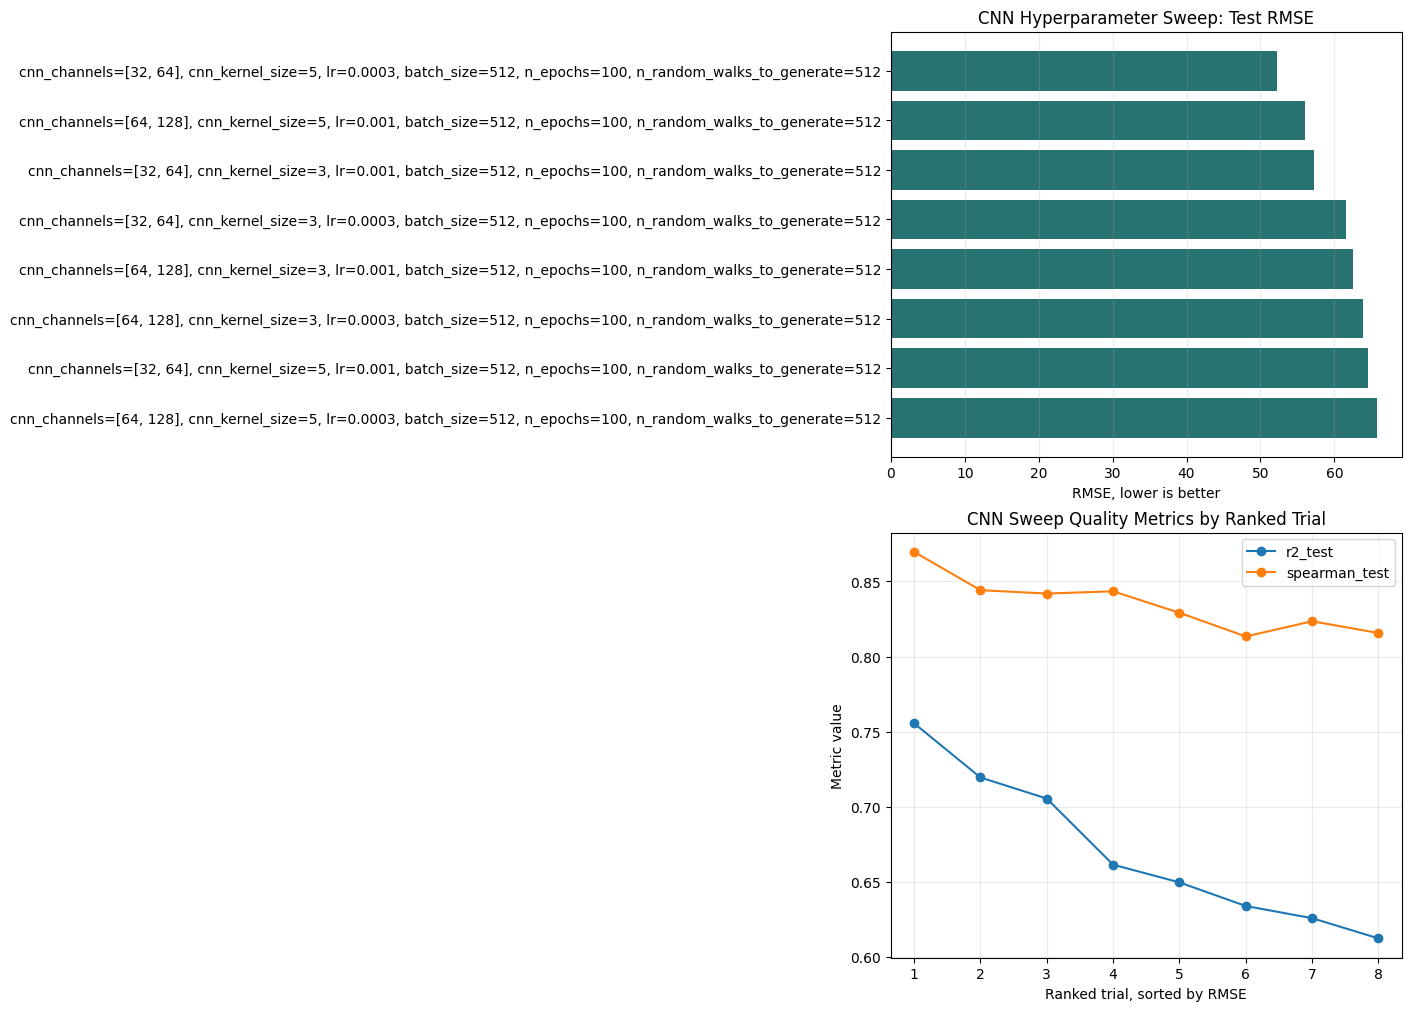

,cnn_channels,cnn_kernel_size,lr,batch_size,n_epochs,n_random_walks_to_generate,n_test_random_walks_to_generate,r2_test,rmse_test,spearman_test,predict_time,test_shape,final_train_loss,trial,config_label
0,"[32, 64]",5,0.0003,512,100,512,256,0.755580,52.228020,0.869649,0.329906,"torch.Size([85027, 28])",0.001356,1,"cnn_channels=[32, 64], cnn_kernel_size=5, lr=0..."
1,"[64, 128]",5,0.0010,512,100,512,256,0.719519,55.976183,0.844138,0.486626,"torch.Size([85043, 28])",0.000700,2,"cnn_channels=[64, 128], cnn_kernel_size=5, lr=..."
2,"[32, 64]",3,0.0010,512,100,512,256,0.705495,57.300409,0.841881,0.358454,"torch.Size([84842, 28])",0.001370,3,"cnn_channels=[32, 64], cnn_kernel_size=3, lr=0..."
3,"[32, 64]",3,0.0003,512,100,512,256,0.661506,61.507649,0.843393,0.328050,"torch.Size([85032, 28])",0.002006,4,"cnn_channels=[32, 64], cnn_kernel_size=3, lr=0..."
4,"[64, 128]",3,0.0010,512,100,512,256,0.649707,62.546409,0.829109,0.333675,"torch.Size([85043, 28])",0.001054,5,"cnn_channels=[64, 128], cnn_kernel_size=3, lr=..."
5,"[64, 128]",3,0.0003,512,100,512,256,0.633996,63.897759,0.813340,0.333765,"torch.Size([85005, 28])",0.001627,6,"cnn_channels=[64, 128], cnn_kernel_size=3, lr=..."
6,"[32, 64]",5,0.0010,512,100,512,256,0.625901,64.532135,0.823443,0.328484,"torch.Size([85039, 28])",0.000967,7,"cnn_channels=[32, 64], cnn_kernel_size=5, lr=0..."
7,"[64, 128]",5,0.0003,512,100,512,256,0.612441,65.809792,0.815646,0.339793,"torch.Size([85076, 28])",0.000992,8,"cnn_channels=[64, 128], cnn_kernel_size=5, lr=..."


In [24]:
if 'df_cnn_sweep' in globals() and isinstance(df_cnn_sweep, pd.DataFrame) and len(df_cnn_sweep) > 0:
    df_plot = df_cnn_sweep.copy().reset_index(drop=True)
    df_plot['trial'] = np.arange(1, len(df_plot) + 1)

    label_cols = [col for col in ['cnn_channels', 'cnn_kernel_size', 'lr', 'batch_size', 'n_epochs', 'n_random_walks_to_generate'] if col in df_plot.columns]
    df_plot['config_label'] = df_plot[label_cols].apply(
        lambda row: ', '.join(f'{col}={row[col]}' for col in label_cols), axis=1
    )

    n_rows = 2 if {'r2_test', 'spearman_test'}.intersection(df_plot.columns) else 1
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 5 * n_rows), constrained_layout=True)
    if n_rows == 1:
        axes = [axes]

    df_rmse = df_plot.sort_values('rmse_test', ascending=True)
    axes[0].barh(df_rmse['config_label'], df_rmse['rmse_test'], color='#287271')
    axes[0].invert_yaxis()
    axes[0].set_title('CNN Hyperparameter Sweep: Test RMSE')
    axes[0].set_xlabel('RMSE, lower is better')
    axes[0].grid(axis='x', alpha=0.25)

    metric_cols = [col for col in ['r2_test', 'spearman_test'] if col in df_plot.columns]
    if metric_cols:
        for col in metric_cols:
            axes[1].plot(df_plot['trial'], df_plot[col], marker='o', label=col)
        axes[1].set_title('CNN Sweep Quality Metrics by Ranked Trial')
        axes[1].set_xlabel('Ranked trial, sorted by RMSE')
        axes[1].set_ylabel('Metric value')
        axes[1].set_xticks(df_plot['trial'])
        axes[1].grid(alpha=0.25)
        axes[1].legend()

    plt.show()
    display(df_plot)
else:
    print('No CNN sweep results to plot. Set CFG[\'run_cnn_hyperparameter_sweep\'] = True and rerun training.')


In [25]:
%%time 

if X_train is not None:
    memory_size = X_train.element_size() * X_train.numel()/10**6
    print(f"Tensor size: {X_train.shape}")
    print(f"Memory size: {memory_size} Mbytes")
else:
    print('No retained X_train tensor to report; sweep mode keeps only the best model and metrics.')

print("model memory:", get_model_memory(model) )
try:
    print(f"Memory allocated: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB")
    print(f"Max memory allocated: {torch.cuda.max_memory_allocated() / (1024 ** 2):.2f} MB")
except Exception as e:
    print(f"Exception occurred: {e}")   
    

if X_train is not None:
    del X_train, y_train

import gc
gc.collect()

# Clean GPU memory
try: 
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
except Exception as e:
    print(f"Exception occurred: {e}")

No retained X_train tensor to report; sweep mode keeps only the best model and metrics.
model memory: 59524
Memory allocated: 131.73 MB
Max memory allocated: 173.19 MB
CPU times: user 148 ms, sys: 11 ms, total: 159 ms
Wall time: 177 ms


# Model Error analysis

## Loss plot (train losses)

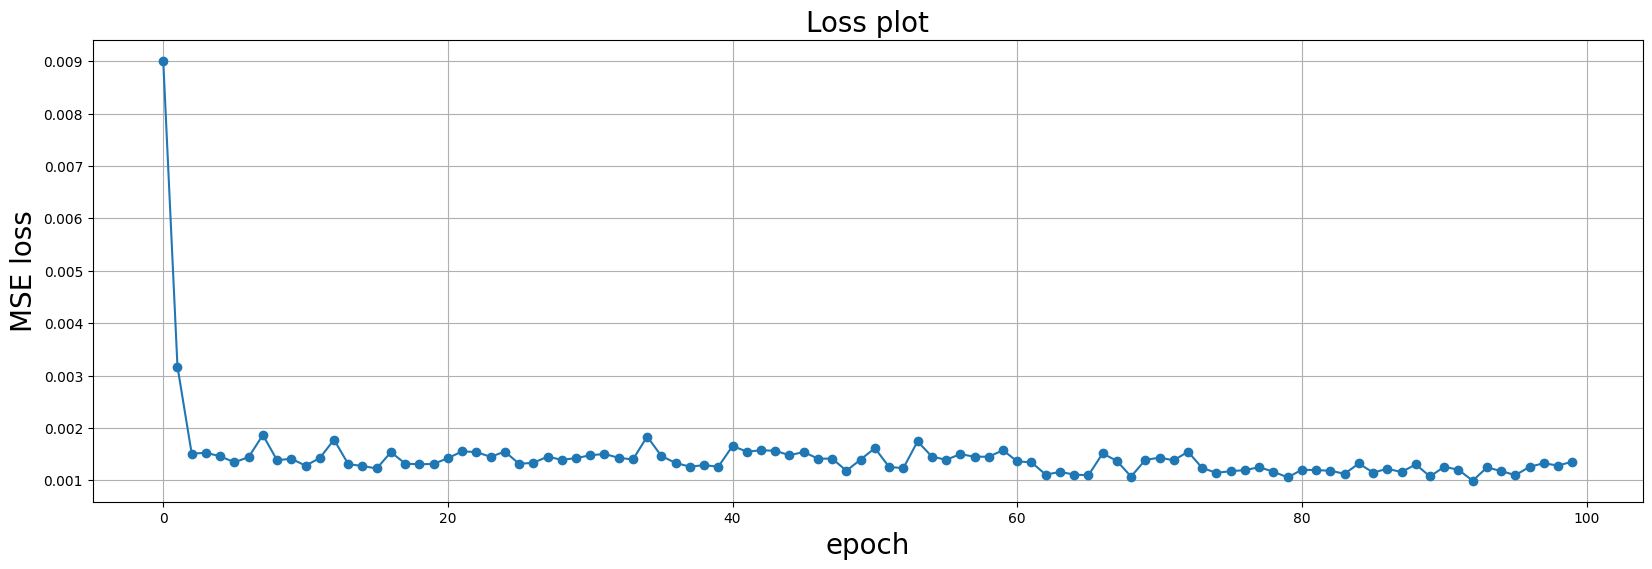

In [62]:
fig = plt.figure(figsize = (20,6 ) )
plt.plot( list_epoch_train_loss, 'o-'  )
plt.title('Loss plot', fontsize = 20 )
plt.xlabel('epoch',fontsize = 20 )
plt.ylabel('MSE loss', fontsize=20)
plt.grid()
plt.show()

In [63]:
%%time
def convert_to_numpy( v1,v2 ):
    if isinstance(v1, torch.Tensor):
        #print('torch')
        v1np = v1.detach().cpu().numpy().reshape(-1,)
    else:
        v1np = v1.reshape(-1,)
    if isinstance(v2, torch.Tensor):
        v2np = v2.detach().cpu().numpy().reshape(-1,)        
    else:
        v2np = v2.reshape(-1,)  
    return v1np,v2np

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 6.44 μs


## Basic statistics on unseen data

In [64]:
%%time
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

target_scale = float(max(n_random_walk_length - 1, 1))
X_test, y_test = random_walks(list_generators, n_random_walk_length=n_random_walk_length,
                                n_random_walks_to_generate=1024,
                                n_random_walks_steps_back_to_ban=n_random_walks_steps_back_to_ban,
                                random_walks_type=random_walks_type,
                                state_rw_start=state_destination)
X_test, y_test = deduplicate_states_with_min_label(X_test, y_test)

batch_size = 1024
test_dataset = TensorDataset(X_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

t0 = time.time()
model.eval()
y_pred_list = []
with torch.no_grad():
    for batch in test_loader:
        batch_X = batch[0].to(device)
        batch_pred = model(batch_X)
        y_pred_list.append(batch_pred.detach().cpu())
predict_time = time.time() - t0

y_pred = torch.cat(y_pred_list).numpy().reshape(-1)
y_pred = restore_regression_targets(y_pred, target_scale)
y_test = y_test.detach().cpu().numpy().reshape(-1)

r2_test = r2_score(y_test, y_pred)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred)))
spearmanr_test = stats.spearmanr(y_test, y_pred).statistic

df_stat = pd.DataFrame()
IX = len(df_stat)+1

df_stat.loc[IX,'Model'] = str_modeling_inf
df_stat.loc[IX,'r2 Test'] = r2_test
df_stat.loc[IX,'rmse Test'] = rmse_test
df_stat.loc[IX,'Spearman Test'] = spearmanr_test
df_stat.loc[IX,'PredictTime'] = np.round(predict_time,3)
df_stat.loc[IX,'Test'] = str(X_test.shape)

df_stat.round(3)


CPU times: user 4.29 s, sys: 146 ms, total: 4.44 s
Wall time: 4.45 s


,Model,r2 Test,rmse Test,Spearman Test,PredictTime,Test
1,CNN_ch64-128_k3_epochs100_rwlen378_n_rw10000,0.704,56.891,0.841,1.195,"torch.Size([335658, 28])"


## Predictions vs steps

<timed exec>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


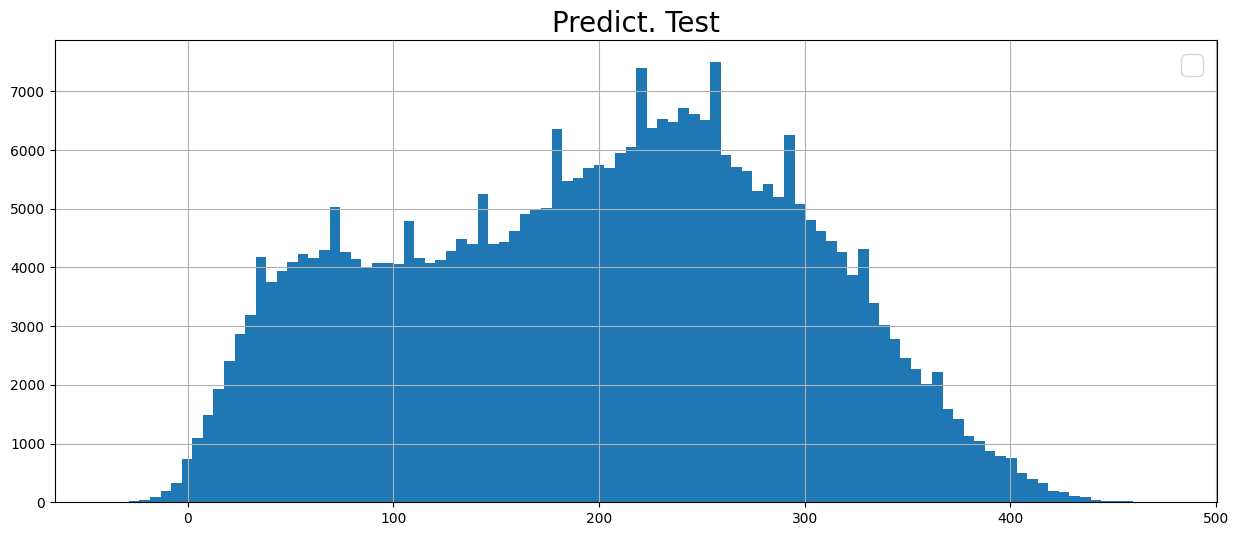

<timed exec>:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


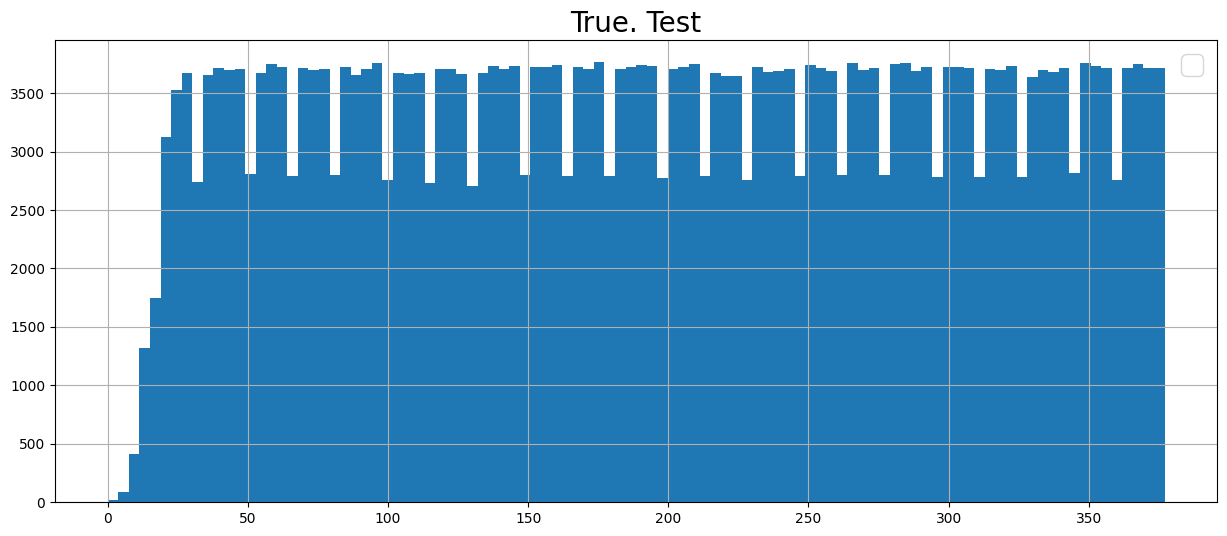

CPU times: user 518 ms, sys: 13.9 ms, total: 532 ms
Wall time: 579 ms


In [65]:
%%time 
y_true = y_test

plt.figure(figsize=(15,6))
plt.hist(np.round(y_pred), bins = 100)
# plt.hist( y_pred, bins = 100)
plt.title('Predict. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()

plt.figure(figsize=(15,6))
plt.hist(y_true, bins = 100)
plt.title('True. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()

## Predictions vs steps

<timed exec>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


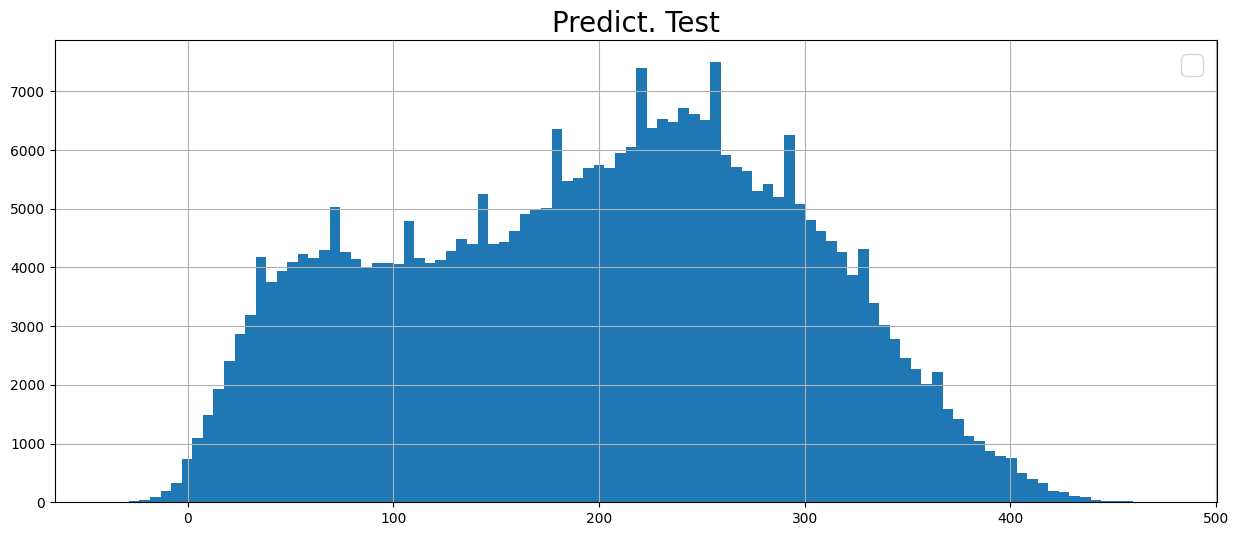

<timed exec>:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


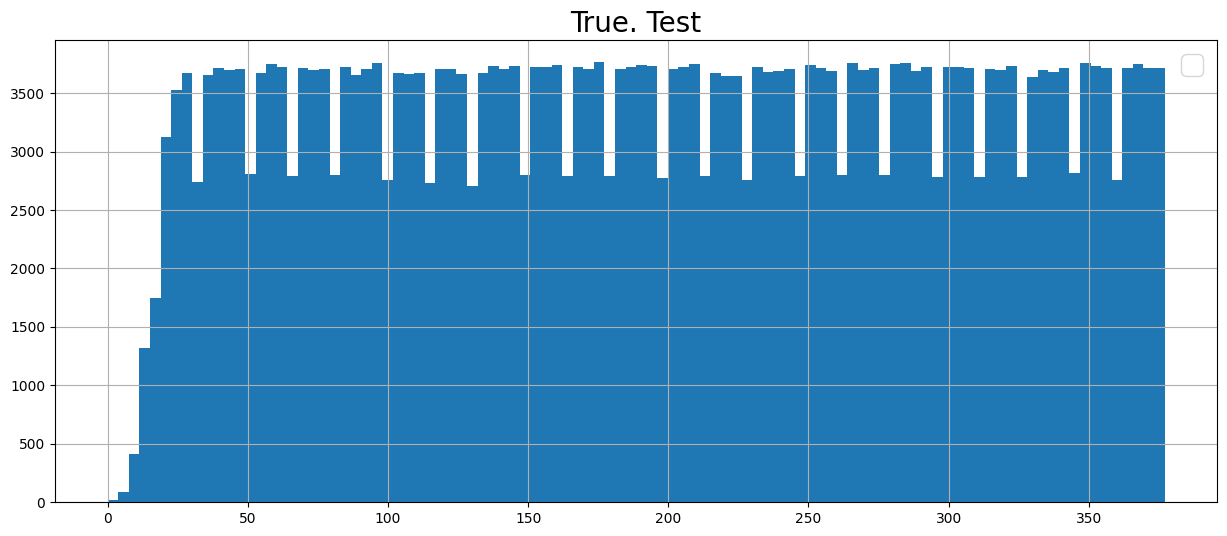

CPU times: user 354 ms, sys: 21.9 ms, total: 376 ms
Wall time: 376 ms


In [66]:
%%time 
y_true = y_test

plt.figure(figsize=(15,6))
plt.hist(np.round(y_pred), bins = 100)
# plt.hist( y_pred, bins = 100)
plt.title('Predict. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()

plt.figure(figsize=(15,6))
plt.hist(y_true, bins = 100)
plt.title('True. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()

## Mean-error plot

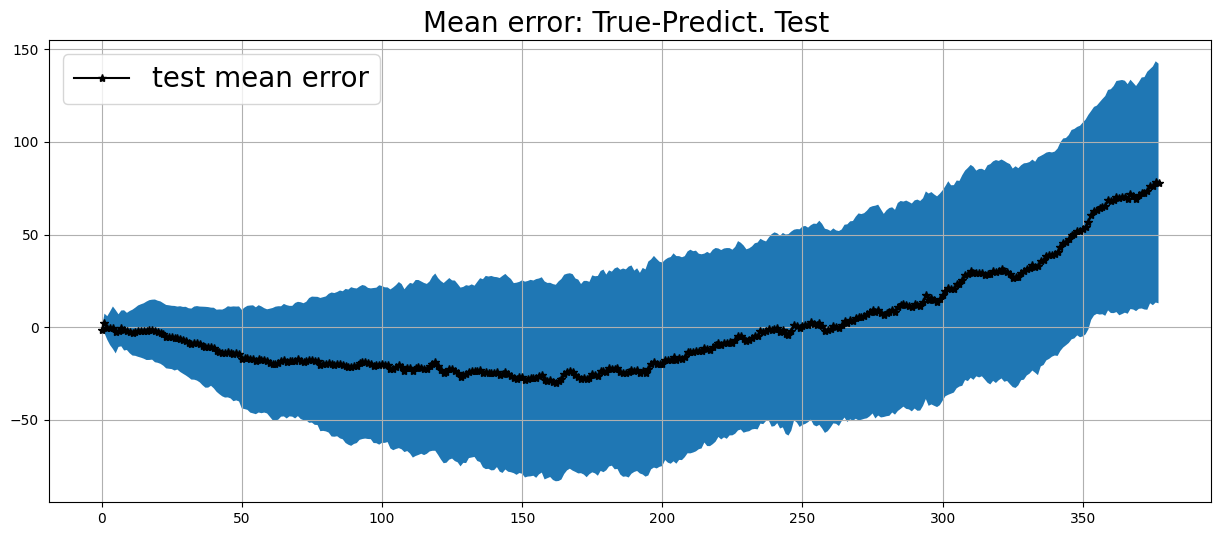

CPU times: user 409 ms, sys: 10.9 ms, total: 420 ms
Wall time: 422 ms


In [67]:
%%time 
list_uv = np.unique(y_test)

y_true = y_test
y_pred = y_pred.reshape(-1,)
df1 = pd.DataFrame()
for k in list_uv:
    mask = y_true == k
    er = np.mean(y_true[mask]- y_pred[mask])
    st = np.std(y_true[mask]- y_pred[mask])
    df1.loc[k,'mean error'] = np.mean(er)
    df1.loc[k,'std'] = st
    
x = df1.index
y = df1['mean error'].values
error =  df1['std'].values
plt.figure(figsize=(15,6))
plt.plot(x,y ,'k*-',  label = 'test mean error')
plt.fill_between(x, y-error, y+error)

plt.title('Mean error: True-Predict. Test ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()

## Error histogram

<timed exec>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


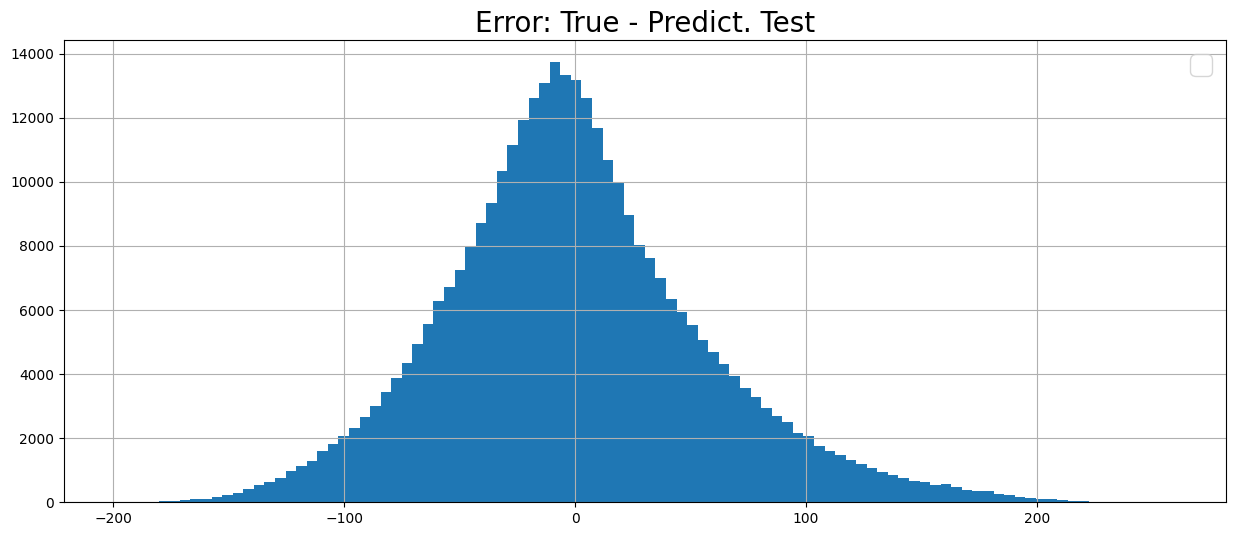

,Test Error,Test Predict
count,335658.000,335658.000
mean,-0.544,197.146
std,56.888,97.867
min,-198.671,-38.529
25%,-36.295,118.275
50%,-4.334,204.651
75%,31.161,272.119
max,259.014,474.985


CPU times: user 203 ms, sys: 14.9 ms, total: 218 ms
Wall time: 218 ms


In [68]:
%%time
df1 = pd.DataFrame()

y_true = y_test
er = y_true - y_pred
df1['Test Error'] = er
df1['Test Predict'] = y_pred
plt.figure(figsize=(15,6))
plt.hist(er, bins = 100)
plt.title('Error: True - Predict. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()


er_stat = df1.describe().round(3)
display(er_stat)
er_stat.to_csv('error_stat.csv')

## Predictions on few trajectories

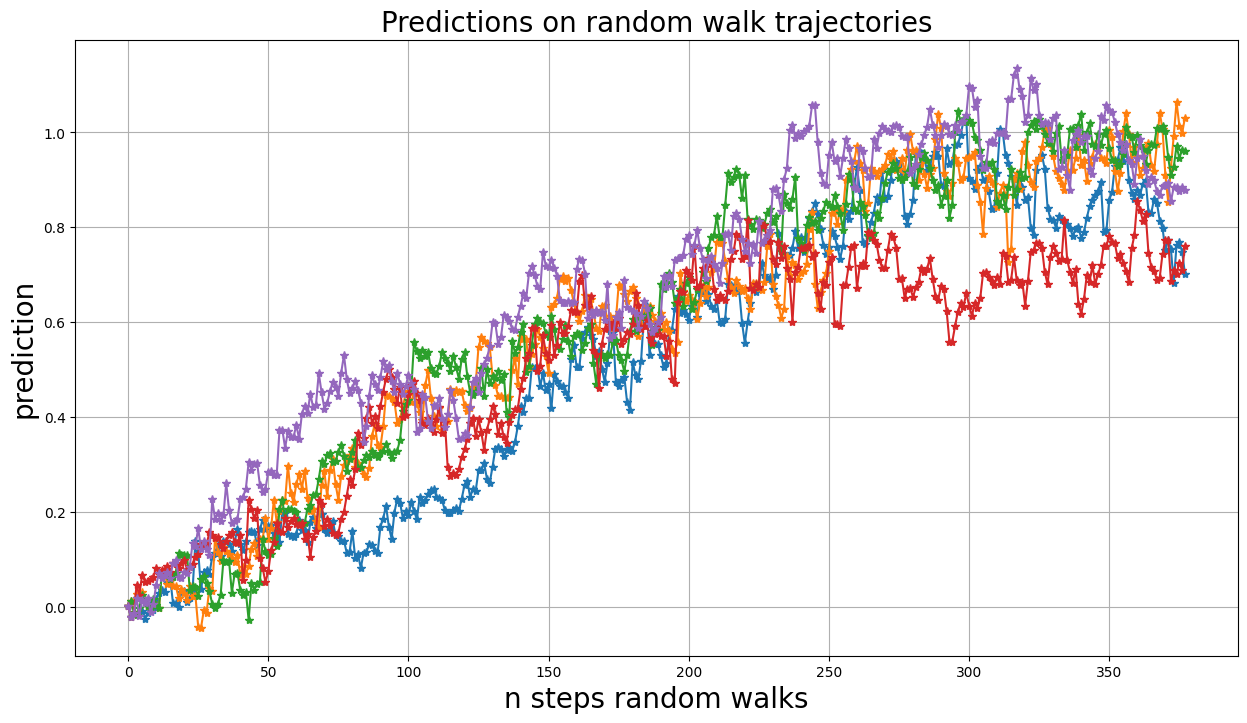

CPU times: user 1.17 s, sys: 32.8 ms, total: 1.2 s
Wall time: 1.21 s


In [69]:
%%time 
plt.figure(figsize=(15,8))

for _ in range(5):
    X_test, y_test = random_walks(list_generators, n_random_walk_length=n_random_walk_length, 
                                    n_random_walks_to_generate=1, 
                                    n_random_walks_steps_back_to_ban = 10, random_walks_type =  'non-backtracking-beam', # 'simple', 
                                    state_rw_start = state_destination)
    
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
    
    y_test , y_pred =  convert_to_numpy( y_test  ,y_pred ) 
    
    
    plt.plot(y_pred, '*-' )
plt.title('Predictions on random walk trajectories', fontsize = 20)
# plt.legend(fontsize = 20 )
plt.xlabel('n steps random walks', fontsize = 20)
plt.ylabel('prediction', fontsize = 20  )
plt.grid()
plt.show()

# BFS compute distances 


Torch implementation - see more details in: https://www.kaggle.com/code/alexandervc/growth-4simple-permutations-torch-gpu/ 


PS

More profound versions: https://www.kaggle.com/code/alexandervc/growth-4batched-permutations-torch-gpu,

Torch: https://www.kaggle.com/code/alexandervc/growth-3-permutations-torch-gpu, support 1 billion draft: https://www.kaggle.com/code/alexandervc/growth-4draft-permutations-torch-gpu

Previous version based on numpy: https://www.kaggle.com/code/alexandervc/growth-2-permutations-with-numpy

That is originally proposed during Santa challenge - see notebook: https://www.kaggle.com/code/alexandervc/santa23-states-distance-generate-save

For matrix groups - we need one more trick for hashing: https://www.kaggle.com/code/alexandervc/groups-growth-fast-compute-heisenberg

More complicated with using disk and batches: https://www.kaggle.com/code/alexandervc/groups-growth-fast-compute-ut5-6-7-8-etc

In [70]:
def get_unique_elements_first_idx(tensor, stable = True ):
    '''
    Returns indices of the unique elements in tensor - taking 
    
    https://stackoverflow.com/a/78807335/625396
    '''
    
    # sort tensor
    sorted_tensor, indices = torch.sort(tensor, stable = stable )
    # find position of jumps
    unique_mask = torch.cat((torch.tensor([True], device = tensor.device), sorted_tensor[1:] != sorted_tensor[:-1]))
    return indices[unique_mask], sorted_tensor[unique_mask]

In [71]:
%%time
def bfs_growth_permutations_torch_simple(generators, # Generators ("moves") defining Cayley graph - list (or array) of permutations (or matrices) 
        center_states = None, # State(s) from which bfs is started, Default: 0,1,2,3,... 
        radius_max = 10000, # Maximul radius to compute, for huge graph and large radius - RAM crashes  
        stop_threshold_total_states = np.inf, # Stop exceeding these threshold in total states                           
        device = None, # device for tensors like GPU or CPU - not used in numpy version
        dtype = None, # datatype for small groups uint8, typically unint16
        vec_hasher  = None, # vector to create hashes, if None will be generated 
        flag_return_all_hashes = True, # return all hashes - a bit more RAM
        flag_return_all_states = True,  # return all constrcuted states - more RAM consumption
        flag_return_list_distances = True, # return list of distances  of all constructed states - a bit more RAM
        verbose = 0, # verbosity 
        ):
    t0 = time.time()
    
    '''
    Run bfs to visit all states on distance <= radius_max from center_states.
    For the Cayley-type graph defined by the generator permutations (input: "generators"),
    and initial state(s) (input: center_states) - default is identity permutation, 
    but we support any input state(s). Thus we cat contstruct Cayley-Schreier coset graphs. 
    
    
    Parameters:
        generators - generators ("moves") defining the Cayley graph, each generator is permutation,
                    can be list of vectors or matrix with each row is vector
        center_states = None, # State(s) from which bfs is started, Default: 0,1,2,3,... 
        radius_max = 10000, # Maximul radius to compute, for huge graph and large radius - RAM crashes  
        device = None, # device for tensors like GPU or CPU - not used in numpy version
        dtype = None, # datatype to store states:  for small groups - uint8, for bigger: uint16
        vec_hasher  = None, # vector to create hashes, if None will be generated 
        flag_return_all_hashes = True, # return all hashes - a bit more RAM
        flag_return_all_states = True,  # return all constrcuted states - more RAM consumption
        flag_return_list_distances = True, # return list of distances  of all constructed states - a bit more RAM
        verbose = 0, # verbosity 
    
    Returns:
        dict_growth - dictionary with 
        dict_additional_data - optional, contains the following:
            vec_hasher  - vector to create hashes (torch tensor)
            list_distances - list distances for each state - same order of states as for hashes, states 
            vec_hashes_all - all hashes of obtained states
            array_states_all - all states 

    That function is calling lower level subfunctions depending on engine and generators type - permutations or matrices
    '''

    ##########################################################################################
    # Analyse input params and convert to stadard forms
    ##########################################################################################
    generators_type = 'permutation' # 'matrix'
    
    # device 
    if device is None:
#         if (center_states is not None) and hasattr(center_states, 'dtype'):
#             device = center_states.device
#         else:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        else:
            device = torch.device("cpu")
    
    
    # Analyse input format of "generators"
    # can be list_generators, or tensor/np.array with rows - generators
    if isinstance(generators, list):
        list_generators = generators
    elif isinstance(generators, torch.Tensor ):
        list_generators = [ list(generators[i,:]) for i in range(generators.shape[0] ) ]       
    elif isinstance(generators, np.ndarray ):
        list_generators = [list(generators[i,:]) for i in range(generators.shape[0] ) ]
    else:
        print('Unsupported format for "generators"', type(generators), generators)
        raise ValueError('Unsupported format for "generators"')
    state_size = len(list_generators[0])
    tensor_all_generators = torch.tensor( list_generators , device = device, dtype = torch.int64)

    # dtype 
    if dtype is None:
        if isinstance(center_states, torch.Tensor ):
            dtype = center_states.dtype
        else:
            if state_size <= 256:
                dtype = torch.uint8
            else:
                dtype = torch.uint16  
                
    # Center state(s)
    if center_states is None:
        center_states = torch.arange( state_size, device=device, dtype = dtype).reshape(1,state_size)
    if not isinstance( center_states , torch.Tensor):
        center_states = torch.tensor( center_states  )
    center_states = center_states.reshape(-1,state_size).to(device)
    
    # Vec_hasher
    if vec_hasher is None:
        # Hash vector generation
        max_int =  int( (2**62) )     #print(max_int)
        dtype_for_hash = torch.int64
        vec_hasher = torch.randint(-max_int, max_int,   size= (state_size,),  device=device, dtype = dtype_for_hash) #
    if not isinstance( vec_hasher , torch.Tensor):
        vec_hasher = torch.tensor( vec_hasher , device=device, dtype = dtype_for_hash )
    
    
    ###################################################################################
    # Prepare output data: 
    ###################################################################################
    # Main output: Growth - dictionary: distance-> how many states
    dict_growth = {0: center_states.shape[0]}
    # Secondary output:
    dict_additional_data = {}
    dict_additional_data['vec_hasher'] = vec_hasher
    # Hashes:
    vec_hashes_all = torch.tensor([], device = device, dtype = vec_hasher.dtype ) # Defined later
    # Distances 
    list_distances = [0]*center_states.shape[0]
    # States  
    array_states_all = center_states.clone()
    
    ##################################################################################
    # Used in process:
    ##################################################################################
    # States 
    array_states_achieved_previous_step = center_states.clone()
    
    # Hashes
    dtype_for_hash = vec_hasher.dtype
    vec_hashes_all = torch.sum(array_states_achieved_previous_step * vec_hasher, dim=1) # Compute hashes. 
        # It is same as matrix product torch.matmul(hash_vec , states ) 
        # but pay attention: such code work with GPU for integers 
        # While torch.matmul - does not work for GPU for integer data types, 
        # since old GPU hardware (before 2020: P100, T4) does not support integer matrix multiplication 
    vec_hashes_previous_step = vec_hashes_all.clone() # Compute hashes. 
    vec_hashes_pre_previous_step = vec_hashes_all.clone()
    vec_hashes_current = vec_hashes_all.clone()
    
    
    ###############################################################################################
    # Main loop over distances:
    ###############################################################################################
    for i_distance in range(1,radius_max+1):
        t_moves = t_hash = t_isin = t_unique_els = 0; t_all = time.time() # Time profiling
        
        # Apply generator to all current states 
        t1 = time.time()
        new_states_candidates = get_neighbors(  array_states_achieved_previous_step ,  tensor_all_generators.to(torch.int64) ).flatten(end_dim=1)
        t_moves += (time.time() - t1)
        
        # Compute hash
        # That can cause RAM crash ! Because new_states_candidates * vec_hasher is created, it will be int64 - so 8 times larger than new_states_candidates
        t1 = time.time()
        vec_hashes_new_all_gens = torch.sum(new_states_candidates * vec_hasher, dim=1) # Compute hashes 
            # That is equivalent to matmul, but matmul is not supported for ints in torch (on GPU <= 2018) - that is way round
        t_hash += (time.time() - t1)        
        
        # Select unique
        t1 = time.time()
        unique_idx,unique_hashes = get_unique_elements_first_idx(vec_hashes_new_all_gens,  stable = False )
        t_unique_els += (time.time() - t1)

        # Select new 
        t1 = time.time()
        mask_new = ~torch.isin(unique_hashes, vec_hashes_current, assume_unique=True)
        t_isin += (time.time() - t1)
        #######################################################
        # End of main operations.
        #######################################################

        n_new_states = mask_new.sum().item()
        # Check Growth finished - no new states can be found:
        if n_new_states == 0: break            
        
        #######################################################
        # Prepare data for the next loop iteration: 
        #######################################################
        
        # Store new states 
        array_new_states = new_states_candidates[unique_idx, : ][mask_new,:]
        array_states_achieved_previous_step = array_new_states

        # Hashes 
        vec_hashes_new_all_gens = unique_hashes[mask_new]
        vec_hashes_pre_previous_step = vec_hashes_previous_step
        vec_hashes_previous_step = vec_hashes_new_all_gens
        vec_hashes_current = torch.cat([vec_hashes_pre_previous_step, vec_hashes_previous_step], dim = 0 )
        
        ###############################################################################
        # Update output data :
        ##############################################################################
        dict_growth[i_distance] = n_new_states       
        if flag_return_list_distances: # return list of distances  of all constructed states - a bit more RAM
            list_distances += [i_distance] * int(array_new_states.shape[0])

        if flag_return_all_hashes: # return all hashes - a bit more RAM consumption
            vec_hashes_all = torch.cat([vec_hashes_all, vec_hashes_new_all_gens], dim = 0  ) 
            #print('vec_hashes_all.shape:', vec_hashes_all.shape, vec_hashes_new_all_gens.shape) 

        if flag_return_all_states: # return all constrcuted states - more RAM consumption
            array_states_all = torch.cat([array_states_all, array_new_states], dim = 0  )         
        
        if verbose >= 10:
            t_all = time.time()-t_all
            print(i_distance,'i_distance',n_new_states, 'new states', 
                 't_all %.3f, t_moves  %.4f, t_hash  %.4f, t_isin %.3f, t_unique_els  %.3f, '%(t_all,t_moves , 
                  t_hash , t_isin , t_unique_els), 'Cummulat Time %.3f'%(time.time()-t0), )        
        
        #print( np.sum( list(dict_growth.values()) ))    
        if np.sum( list(dict_growth.values()) ) >= stop_threshold_total_states:
            break
        
    ##########################################################################################
    # Finalize output:
    ##########################################################################################
    if flag_return_all_hashes: # return all hashes - a bit more RAM consumption
        dict_additional_data['vec_hashes_all'] = vec_hashes_all
        
    if flag_return_all_states: # return all constrcuted states - more RAM consumption
        dict_additional_data['array_states_all'] = array_states_all
        
    if flag_return_list_distances: # return list of distances  of all constructed states - a bit more RAM
        dict_additional_data['list_distances'] = list_distances

    return dict_growth, dict_additional_data

def bfs_growth(generators, # Generators ("moves") defining Cayley graph - list (or array) of permutations (or matrices) 
        center_states = None, # State(s) from which bfs is started, Default: 0,1,2,3,... 
        radius_max = 10000, # Maximul radius to compute, for huge graph and large radius - RAM crashes  
        stop_threshold_total_states = np.inf, # Stop exceeding these threshold in total states 
        device = None, # device for tensors like GPU or CPU - not used in numpy version
        dtype = None, # datatype for small groups uint8, typically unint16
        vec_hasher  = None, # vector to create hashes, if None will be generated 
        flag_return_all_hashes = True, # return all hashes - a bit more RAM
        flag_return_all_states = True,  # return all constrcuted states - more RAM consumption
        flag_return_list_distances = True, # return list of distances  of all constructed states - a bit more RAM
        batch_size_states = 1024*1024, # Batch-size for the process. Huge batch may crash RAM 
        verbose = 0, # verbosity 
        work_mode = 'to-do', # several methods with hashes and one without 
        engine = 'torch',# numpy, torch - what engine to use
        ):
    
    dict_growth, dict_additional_data = bfs_growth_permutations_torch_simple(generators, # Generators ("moves") defining Cayley graph - list (or array) of permutations (or matrices) 
        center_states = center_states, # State(s) from which bfs is started, Default: 0,1,2,3,... 
        radius_max = radius_max, # Maximul radius to compute, for huge graph and large radius - RAM crashes  
        stop_threshold_total_states = stop_threshold_total_states, # Stop exceeding these threshold in total states 
        device = device, # device for tensors like GPU or CPU - not used in numpy version
        dtype = dtype, # datatype for small groups uint8, typically unint16
        vec_hasher  = vec_hasher, # vector to create hashes, if None will be generated 
        flag_return_all_hashes = flag_return_all_hashes, # return all hashes - a bit more RAM
        flag_return_all_states = flag_return_all_states,  # return all constrcuted states - more RAM consumption
        flag_return_list_distances = flag_return_list_distances, # return list of distances  of all constructed states - a bit more RAM
        #batch_size_states = batch_size_states, # Batch-size for the process. Huge batch may crash RAM 
        verbose = verbose, # verbosity 
        )
    return dict_growth, dict_additional_data


# Also: https://www.cube20.org/qtm/
# cube_3/3/3_12gensQTM 6_color
# Total: 9205558 growth: {0: 1, 1: 12, 2: 114, 3: 1068, 4: 10011, 5: 93840, 6: 878880, 7: 8221632, 8: 76843595}}
# Growth factors: [12.   9.5  9.4  9.4  9.4  9.4  9.4]
# print(dict_growth )    

CPU times: user 10 μs, sys: 0 ns, total: 10 μs
Wall time: 13.4 μs


In [36]:
%%time 

# verbose = 10
# flag_return_all_hashes = True#, # return all hashes - a bit more RAM
# flag_return_all_states = True# False#,  # return all constrcuted states - more RAM consumption
# flag_return_list_distances = True# False#, # return list of distances  of all constructed states - a bit more RAM

radius_max = 30# , # Maximul radius to compute, for huge graph and large radius - RAM crashes  
stop_threshold_total_states = 10**6

# group_gens_id = 'cube_2/2/2_6gensQTM' # group_gens_id = 'cube_2/2/2'#_6gensQTM' 
# #group_gens_id = 'cube_3/3/3_12gensQTM'
# list_generators = list( get_dict_generators( group_gens_id ).values() )

dict_growth, dict_additional_data = bfs_growth(list_generators, 
                           center_states =  state_destination,        
                           radius_max = radius_max, 
                           stop_threshold_total_states = stop_threshold_total_states, # Stop exceeding these threshold in total states 
                           flag_return_all_states = True, flag_return_all_hashes = True, flag_return_list_distances = True,
                           device = device, dtype = dtype,
                           vec_hasher = vec_hasher,  verbose = 10 )

array_states_all_saved =  dict_additional_data['array_states_all']
list_distances_save = dict_additional_data['list_distances']

print()
print('Result - dict_growth:')
print(dict_growth)
print('Total states:', np.sum( list(dict_growth.values()) ))
print()

# 'cube_2/2/2_6gensQTM'
# Total: 3674160 growth: 
# {0: 1, 1: 6, 2: 27, 3: 120, 4: 534, 5: 2256, 6: 8969, 7: 33058, 8: 114149, 9: 360508, 10: 930588, 11: 1350852, 12: 782536, 13: 90280, 14: 276}
# https://en.wikipedia.org/wiki/Pocket_Cube

print('Result - dict_additional_data - keys:')
print(dict_additional_data.keys() ) # ['vec_hasher', 'vec_hashes_all', 'array_states_all', 'list_distances']
print()

print('vec_hasher')
print(dict_additional_data['vec_hasher']) 
print()

print('list_distances 100 first: ')
print(dict_additional_data['list_distances'][:100]) 
print()

print('vec_hashes_all  5 first: ')
print(dict_additional_data['vec_hashes_all'][:5]) 
print()

print('array_states_all 2 first:')
print(dict_additional_data['array_states_all'][:2,:]) 
print()

1 i_distance 3 new states t_all 2.033, t_moves  0.0637, t_hash  0.0001, t_isin 1.943, t_unique_els  0.026,  Cummulat Time 2.033
2 i_distance 5 new states t_all 0.001, t_moves  0.0003, t_hash  0.0000, t_isin 0.000, t_unique_els  0.000,  Cummulat Time 2.034
3 i_distance 8 new states t_all 0.001, t_moves  0.0001, t_hash  0.0000, t_isin 0.000, t_unique_els  0.000,  Cummulat Time 2.035
4 i_distance 12 new states t_all 0.001, t_moves  0.0001, t_hash  0.0000, t_isin 0.000, t_unique_els  0.000,  Cummulat Time 2.035
5 i_distance 17 new states t_all 0.001, t_moves  0.0000, t_hash  0.0000, t_isin 0.000, t_unique_els  0.000,  Cummulat Time 2.036
6 i_distance 25 new states t_all 0.001, t_moves  0.0001, t_hash  0.0000, t_isin 0.000, t_unique_els  0.000,  Cummulat Time 2.037
7 i_distance 37 new states t_all 0.001, t_moves  0.0001, t_hash  0.0000, t_isin 0.000, t_unique_els  0.000,  Cummulat Time 2.037
8 i_distance 54 new states t_all 0.001, t_moves  0.0001, t_hash  0.0000, t_isin 0.000, t_unique_els 

In [72]:
print('array_states_all_saved.shape',array_states_all_saved.shape)
print('array_states_all_saved first 5:',array_states_all_saved[:5,:])
print()
print('len(list_distances_save)',len(list_distances_save) )
print('list_distances_save first 10:',list_distances_save[:10] )

array_states_all_saved.shape torch.Size([369206, 28])
array_states_all_saved first 5: tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27],
        [ 0,  2,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27],
        [ 1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10, 13, 12, 15, 14, 17, 16,
         19, 18, 21, 20, 23, 22, 25, 24, 27, 26],
        [ 0,  2,  1,  4,  3,  6,  5,  8,  7, 10,  9, 12, 11, 14, 13, 16, 15, 18,
         17, 20, 19, 22, 21, 24, 23, 26, 25, 27],
        [ 0,  1,  2,  4,  3,  6,  5,  8,  7, 10,  9, 12, 11, 14, 13, 16, 15, 18,
         17, 20, 19, 22, 21, 24, 23, 26, 25, 27]], device='cuda:0')

len(list_distances_save) 369206
list_distances_save first 10: [0, 1, 1, 1, 2, 2, 2, 2, 2, 3]


## Slow simple growth computation 

In [73]:
%%time 
def get_hash(state):
    return hash( str(state) ) # do not use tuple(state) - it produce different hashes for same states

t1 = time.time()
state_initial = state_destination
list_growth = [1] # 1 state on distance 0
list_all_states = [ state_initial]
list_current_states = [ state_initial]
list_distances = [0]
set_hash = set();  set_hash.add(  get_hash(state_initial )  )

for depth in range(1, 500):
    list_new_states = []
    for g in list_generators:
        for s in list_current_states:
            new_state = s[g]
            
            # print(type(new_state));break
            h = get_hash(new_state)
            if h not in set_hash:
                set_hash.add( h  )
                list_new_states.append(new_state)
                #print(new_state, h)
    if len(list_new_states) == 0: break
    list_all_states +=   list_new_states   
    list_growth.append( len(list_new_states ))
    list_distances += [ depth ] * len(list_new_states )
    list_current_states = list_new_states
    print('depth',depth,'n_new_states:',len(list_new_states ), 'Time %.1f'%(time.time() - t1)  )
    if len(list_all_states) >= 10**3: break 
        
print('sum:', np.sum(list_growth ))
print( list_growth     )

depth 1 n_new_states: 3 Time 0.0
depth 2 n_new_states: 5 Time 0.0
depth 3 n_new_states: 8 Time 0.0
depth 4 n_new_states: 12 Time 0.0
depth 5 n_new_states: 17 Time 0.0
depth 6 n_new_states: 25 Time 0.1
depth 7 n_new_states: 37 Time 0.1
depth 8 n_new_states: 54 Time 0.1
depth 9 n_new_states: 79 Time 0.2
depth 10 n_new_states: 116 Time 0.3
depth 11 n_new_states: 170 Time 0.5
depth 12 n_new_states: 244 Time 0.7
depth 13 n_new_states: 343 Time 1.0
sum: 1114
[1, 3, 5, 8, 12, 17, 25, 37, 54, 79, 116, 170, 244, 343]
CPU times: user 1.02 s, sys: 994 μs, total: 1.02 s
Wall time: 1.03 s



# Predictions vs true distances 

<timed exec>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


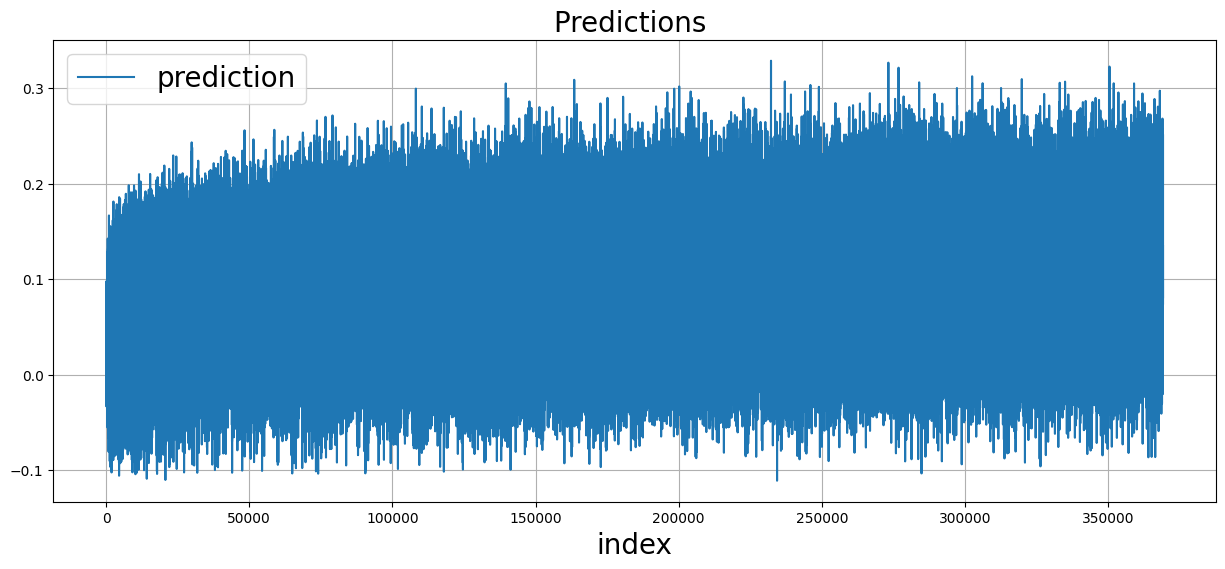

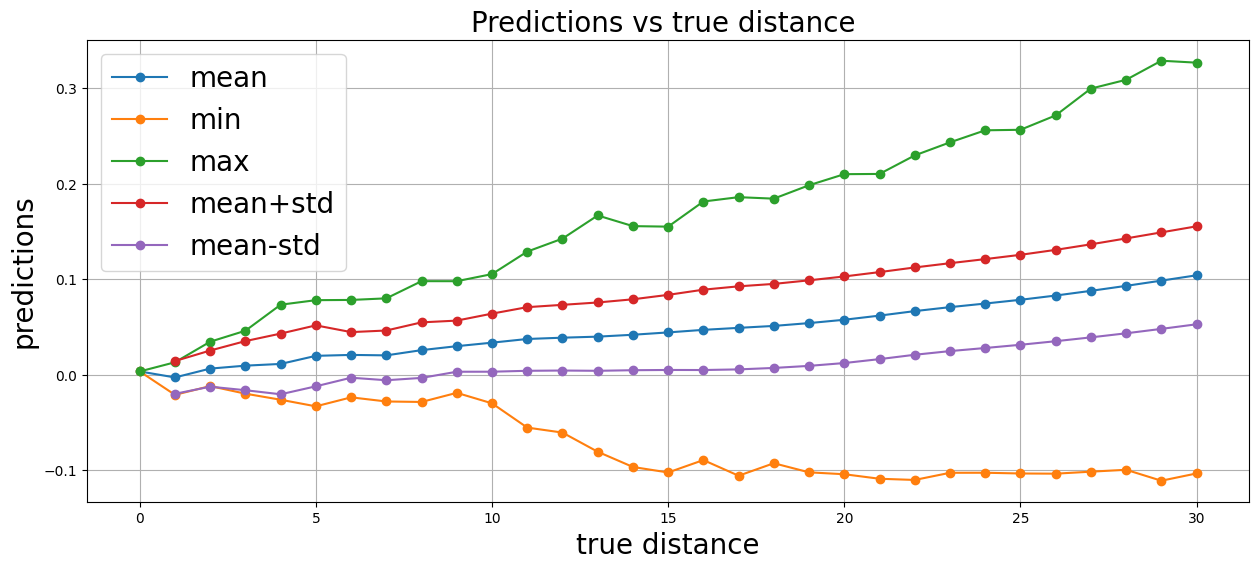

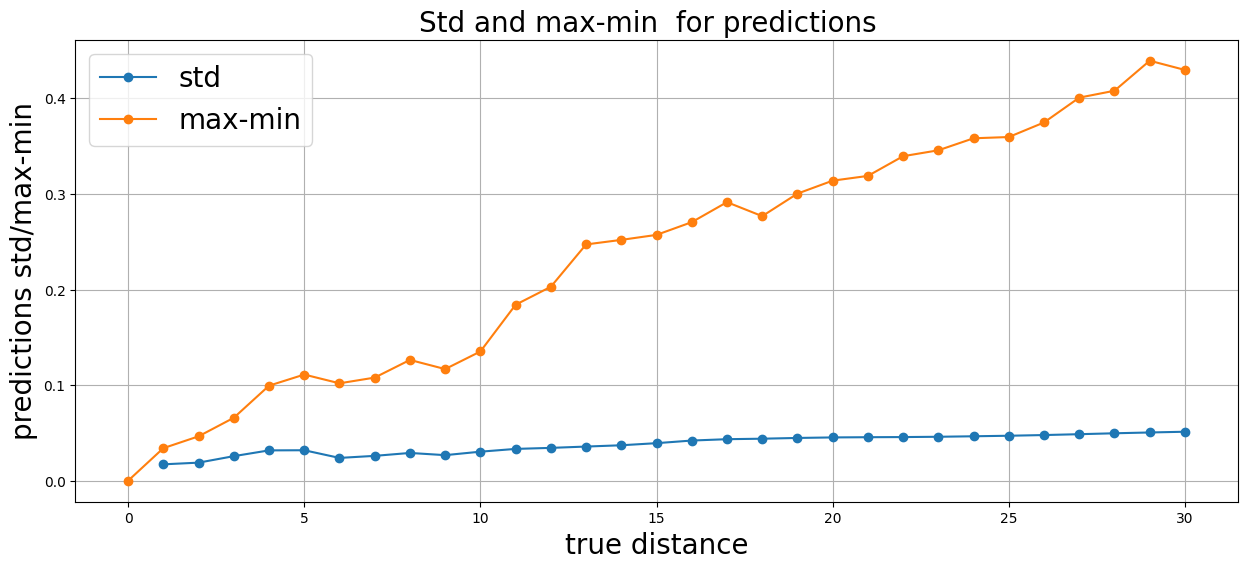

<timed exec>:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


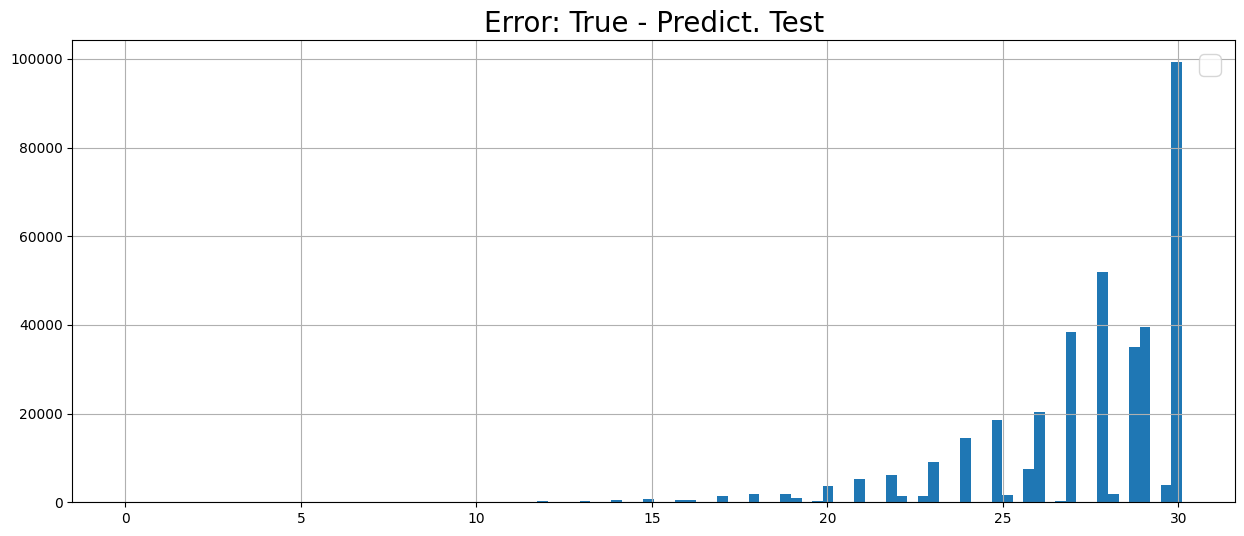

CPU times: user 3.14 s, sys: 95.5 ms, total: 3.23 s
Wall time: 3.24 s


,Model,Spearman,Pearson,PredictTime,Test
1,CNN_ch64-128_k3_epochs100_rwlen378_n_rw10000,0.24,0.26,1.195,"torch.Size([378, 28])"


In [74]:
%%time
# all_states = torch.zeros( size = (len(list_all_states), list_all_states[0].shape[0] ),  dtype =dtype, device = device )
# for k in range(len(list_all_states)):
#     all_states[k,:] = list_all_states[k]

all_states = array_states_all_saved
list_distances = list_distances_save

# model.eval()
# with torch.no_grad():
#     y_pred = model(all_states)
batch_size = 1024 

all_states_tensor = torch.tensor(all_states, dtype=torch.float32)
dataset = TensorDataset(all_states_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size)

# Batched prediction
model.eval()
y_pred_list = []

with torch.no_grad():
    for batch in dataloader:
        batch_states = batch[0].to(device)
        batch_pred = model(batch_states)
        y_pred_list.append(batch_pred.detach().cpu())

y_pred = torch.cat(y_pred_list).numpy().ravel()
y_test = np.array(list_distances)

# y_pred = y_pred.detach().cpu().numpy().ravel() #  =  convert_to_numpy( y_pred  ,y_pred ) 
# y_test = np.array( list_distances )

plt.figure(figsize=(15,6))
plt.plot(y_pred, label='prediction')
plt.title('Predictions ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('index',fontsize = 20 )
plt.grid()
plt.show()

d = pd.DataFrame()
d['pred'] = y_pred
d['true'] = y_test
res = d.groupby('true')['pred'].agg(['mean', 'min', 'max'])
st = d.groupby('true')['pred'].agg(['std'])
plt.figure(figsize=(15,6))
plt.plot(res, 'o-',label = res.columns )
plt.plot(res['mean']+st['std'], 'o-',label = 'mean+std' )
plt.plot(res['mean']-st['std'], 'o-',label = 'mean-std' )
plt.title('Predictions vs true distance ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions',fontsize = 20 )
plt.grid()
plt.show()

plt.figure(figsize=(15,6))
plt.plot(st['std'], 'o-', label = 'std' )
plt.plot(res['max']-res['min'],'o-', label = 'max-min' )
plt.title('Std and max-min  for predictions  ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions std/max-min',fontsize = 20 )
plt.grid()
plt.show()


y_true = y_test
er = y_true - y_pred
plt.figure(figsize=(15,6))
plt.hist(er, bins = 100)
plt.title('Error: True - Predict. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()


r2_test = r2_score(y_test, y_pred)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred)))
spearmanr_test = stats.spearmanr(y_test, y_pred).statistic
pearson_test = np.corrcoef(y_test, y_pred)[0,1]
#res.statistic


df_stat = pd.DataFrame()
IX = len(df_stat)+1

df_stat.loc[IX,'Model'] = str_modeling_inf
# df_stat.loc[IX,'r2 Test'] = r2_test
#df_stat.loc[IX,'r2 Train'] = r2_train
# df_stat.loc[IX,'rmse Test'] = rmse_test
#df_stat.loc[IX,'rmse Train'] = rmse_train
df_stat.loc[IX,'Spearman'] = spearmanr_test
df_stat.loc[IX,'Pearson'] = pearson_test
#df_stat.loc[IX,'Spearman Train'] = spearmanr_train
#df_stat.loc[IX,'FitTime'] = np.round(fit_time,3)
df_stat.loc[IX,'PredictTime'] = np.round(predict_time,3)
#df_stat.loc[IX,'Train'] = str(X_train.shape)
df_stat.loc[IX,'Test'] = str(X_test.shape)

df_stat.round(3)

# Q-learning (one step) i.e. Bellman's equation  - demo example 

Demo example - take all states computed by BFS and apply Q-learning/Bellman's update rule -- 
typically we expect small improvement of correlations Peason/Spearmen with true values.

The price is computing models inference - which might be costly. 

    Bellman's equation for value function on graph:
    V(g) = 1 + min_{neigb} V (neigb )

In our case value function are predictions of the neural network. 



<timed exec>:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


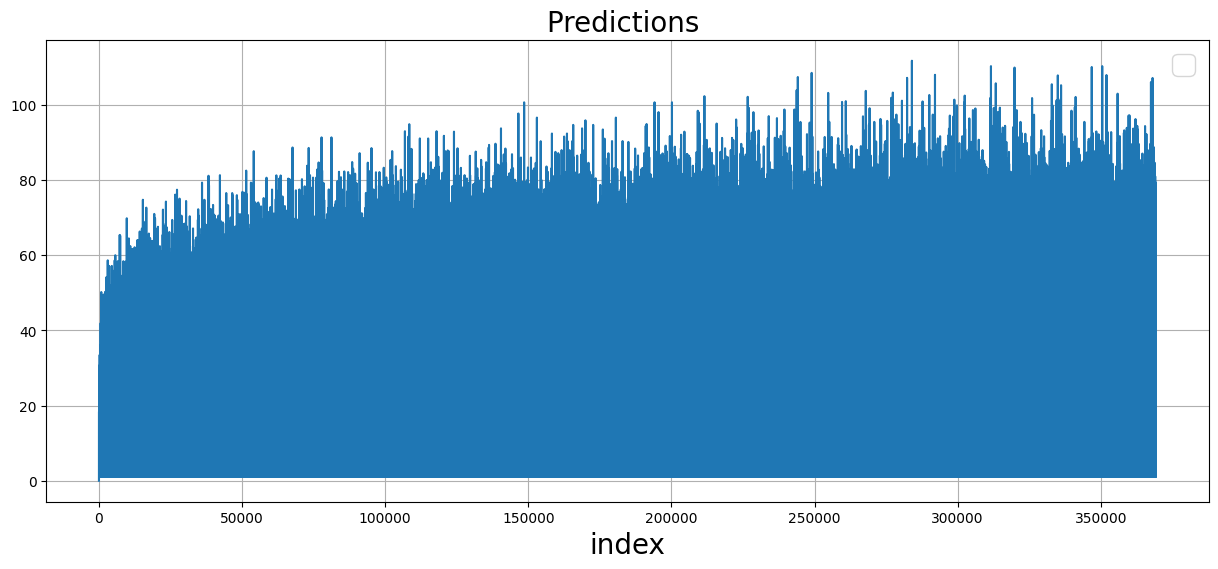

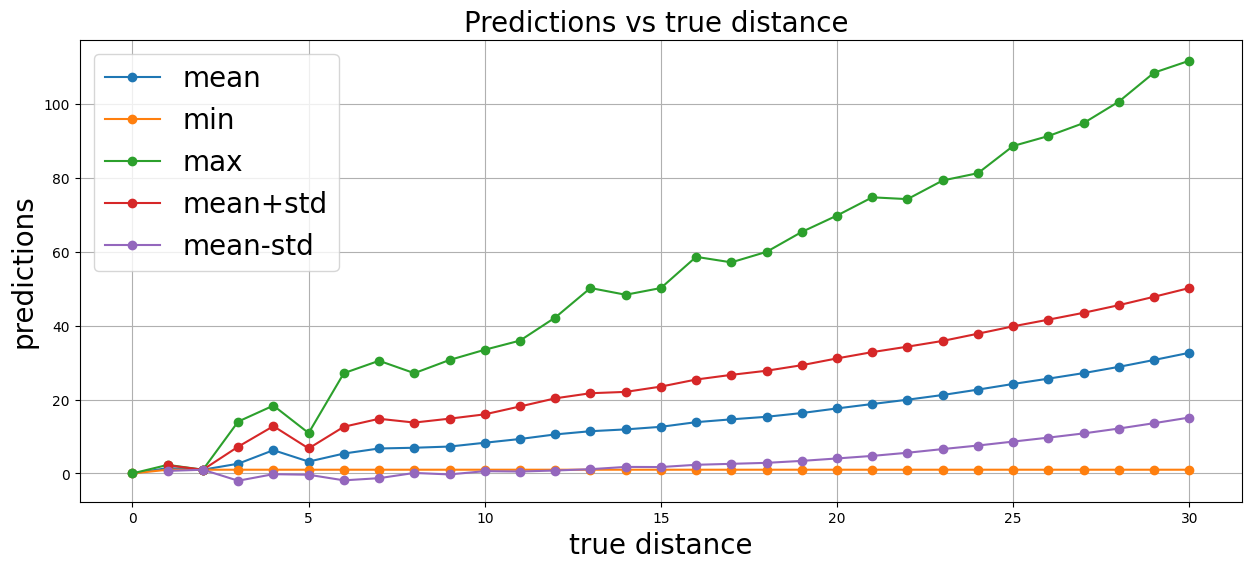

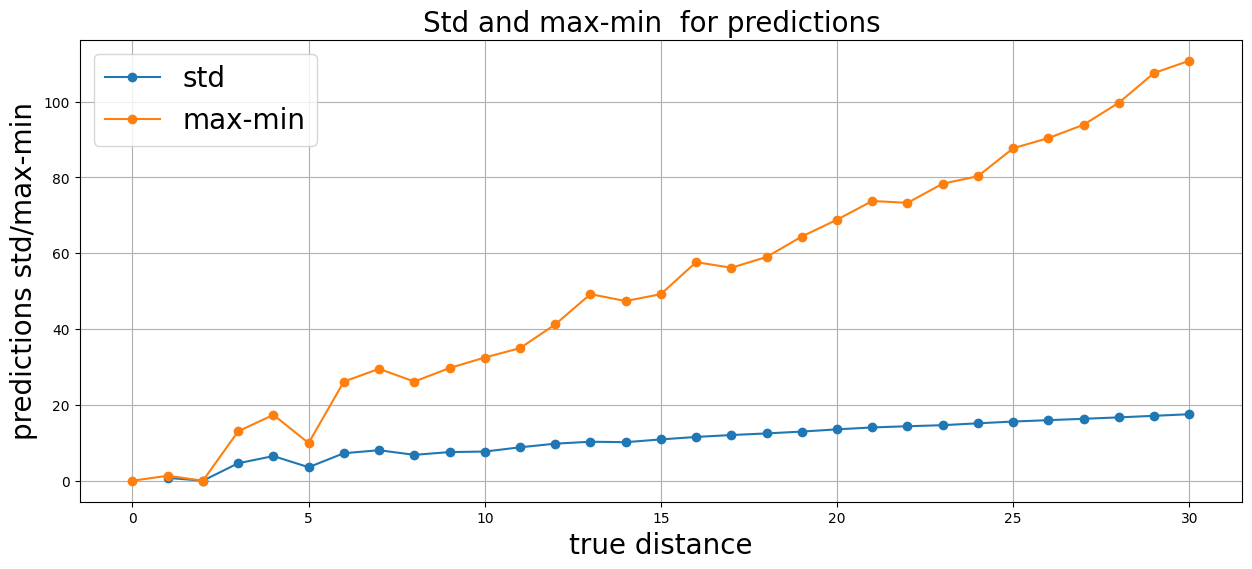

<timed exec>:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


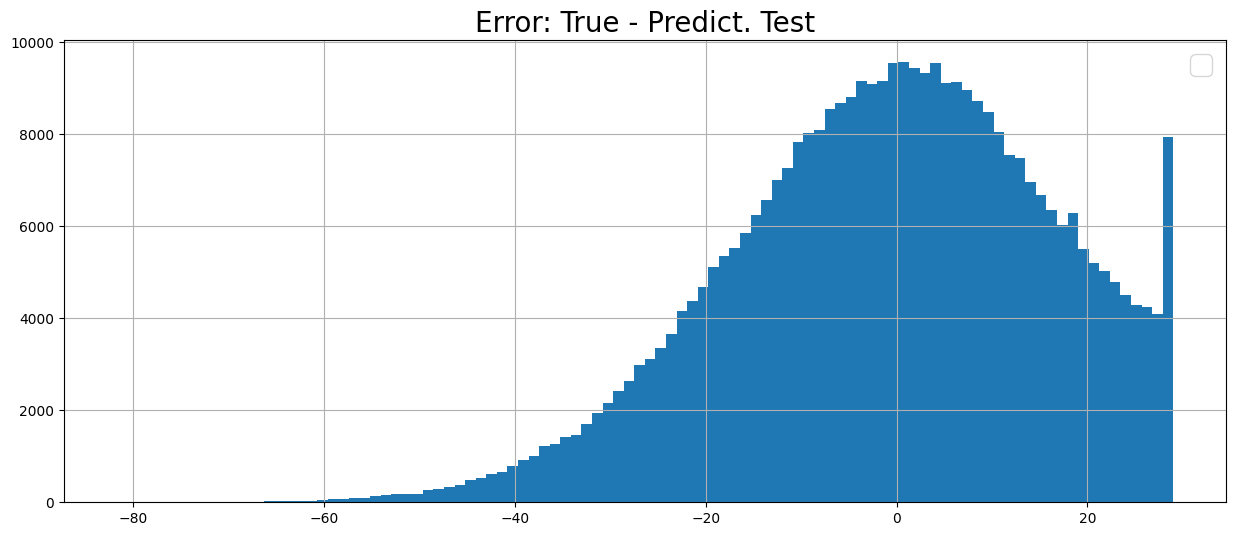

CPU times: user 2.18 s, sys: 153 ms, total: 2.33 s
Wall time: 2.33 s


,Model,Spearman,Pearson,PredictTime,Test
1,CNN_ch64-128_k3_epochs100_rwlen378_n_rw10000,0.239,0.257,1.195,"torch.Size([378, 28])"


In [75]:
%%time

# # Take all states constructed by BFS - convert them to torch tensor
# all_states = torch.zeros( size = (len(list_all_states), list_all_states[0].shape[0] ),  dtype =dtype, device = device )
# for k in range(len(list_all_states)):
#     all_states[k,:] = list_all_states[k]


all_states = array_states_all_saved
list_distances = list_distances_save
    
# Compute their neigbours
neigb = get_neighbors(all_states, tensor_generators)
# print( neigb.shape )
      
# Compute model predictions

neigb_flat = neigb.reshape(-1, neigb.shape[-1])
y_pred = torch.zeros((neigb_flat.shape[0], 1), device=device)
batch_size_loc = 1024
model.eval()
with torch.no_grad():
    for i_batch in range(0, neigb_flat.shape[0], batch_size_loc):
        i_end_batch = min(i_batch + batch_size_loc, neigb_flat.shape[0])
        y_pred[i_batch:i_end_batch] = model(neigb_flat[i_batch:i_end_batch])

y_pred = y_pred.reshape(neigb.shape[0], neigb.shape[1], 1)

target_scale = float(max(CFG['n_random_walk_length'] - 1, 1))
y_pred = restore_regression_targets(y_pred, target_scale)

# print( y_pred.shape )

# Bellman's equation / Q-learning for graphs update: 
# V(g) = 1 + min_{neigb} V (neigb ) 
y_pred = 1 + torch.min(y_pred, dim=1)[0]

# Clip everthing to 1 and origin to 0
y_pred = torch.clamp_min(y_pred, 1 ) 
# Boundary condition - origin is in zero: 
y_pred[0]=0

# y_pred = torch.round(y_pred)



#######################################################################################
# Plots for error analysis
#######################################################################################

y_pred = y_pred.detach().cpu().numpy().ravel() #  =  convert_to_numpy( y_pred  ,y_pred ) 
y_test = np.array( list_distances )

plt.figure(figsize=(15,6))
plt.plot(y_pred )
plt.title('Predictions ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('index',fontsize = 20 )
plt.grid()
plt.show()

d = pd.DataFrame()
d['pred'] = y_pred
d['true'] = y_test
res = d.groupby('true')['pred'].agg(['mean', 'min', 'max'])
st = d.groupby('true')['pred'].agg(['std'])
plt.figure(figsize=(15,6))
plt.plot(res, 'o-',label = res.columns )
plt.plot(res['mean']+st['std'], 'o-',label = 'mean+std' )
plt.plot(res['mean']-st['std'], 'o-',label = 'mean-std' )
plt.title('Predictions vs true distance ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions',fontsize = 20 )
plt.grid()
plt.show()

plt.figure(figsize=(15,6))
plt.plot(st['std'], 'o-', label = 'std' )
plt.plot(res['max']-res['min'],'o-', label = 'max-min' )
plt.title('Std and max-min  for predictions  ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions std/max-min',fontsize = 20 )
plt.grid()
plt.show()

y_true = y_test
er = y_true - y_pred
plt.figure(figsize=(15,6))
plt.hist(er, bins = 100)
plt.title('Error: True - Predict. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()


r2_test = r2_score(y_test, y_pred)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred)))
spearmanr_test = stats.spearmanr(y_test, y_pred).statistic
pearson_test = np.corrcoef(y_test, y_pred)[0,1]
#res.statistic


df_stat = pd.DataFrame()
IX = len(df_stat)+1

df_stat.loc[IX,'Model'] = str_modeling_inf
# df_stat.loc[IX,'r2 Test'] = r2_test
#df_stat.loc[IX,'r2 Train'] = r2_train
# df_stat.loc[IX,'rmse Test'] = rmse_test
#df_stat.loc[IX,'rmse Train'] = rmse_train
df_stat.loc[IX,'Spearman'] = spearmanr_test
df_stat.loc[IX,'Pearson'] = pearson_test
#df_stat.loc[IX,'Spearman Train'] = spearmanr_train
#df_stat.loc[IX,'FitTime'] = np.round(fit_time,3)
df_stat.loc[IX,'PredictTime'] = np.round(predict_time,3)
#df_stat.loc[IX,'Train'] = str(X_train.shape)
df_stat.loc[IX,'Test'] = str(X_test.shape)

df_stat.round(3)

## Check effect of "round" (distnaces are integers) - does not seem to improve

<timed exec>:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


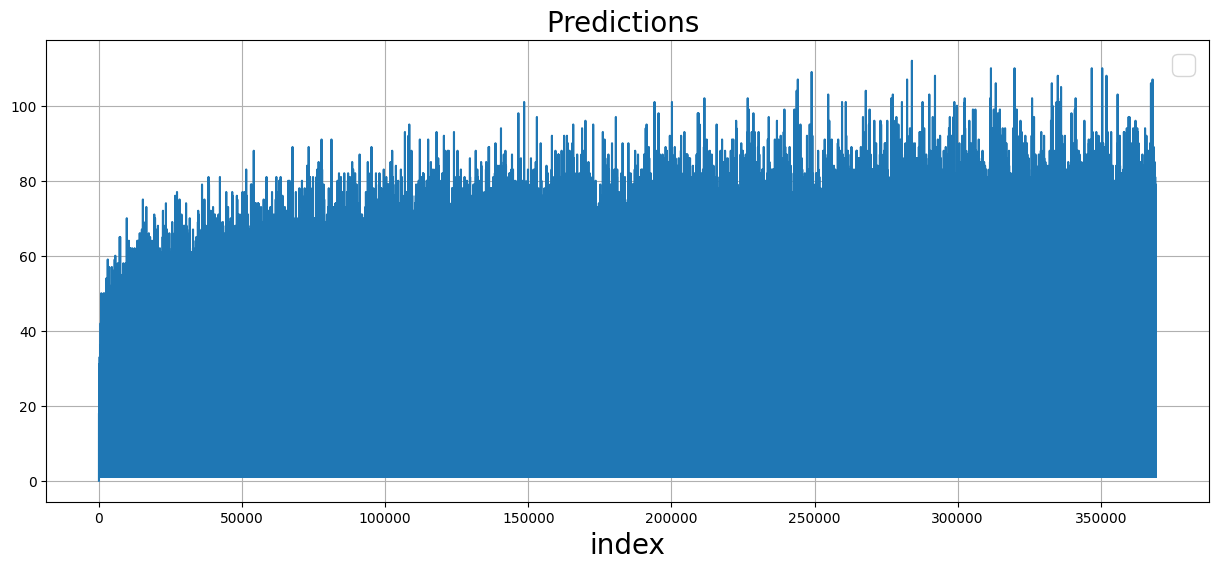

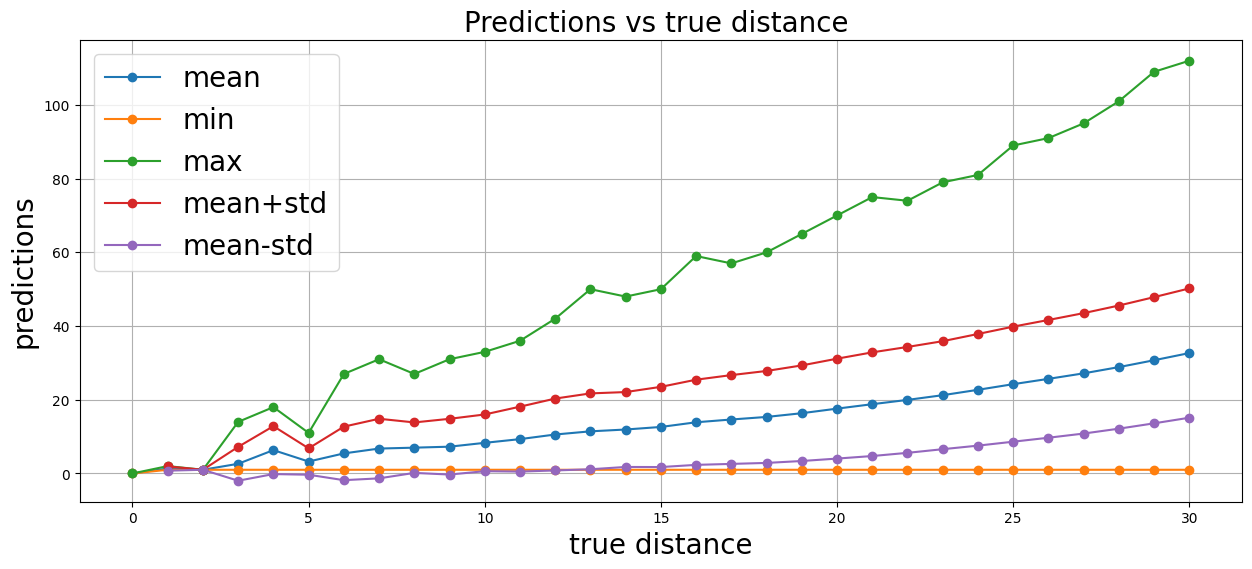

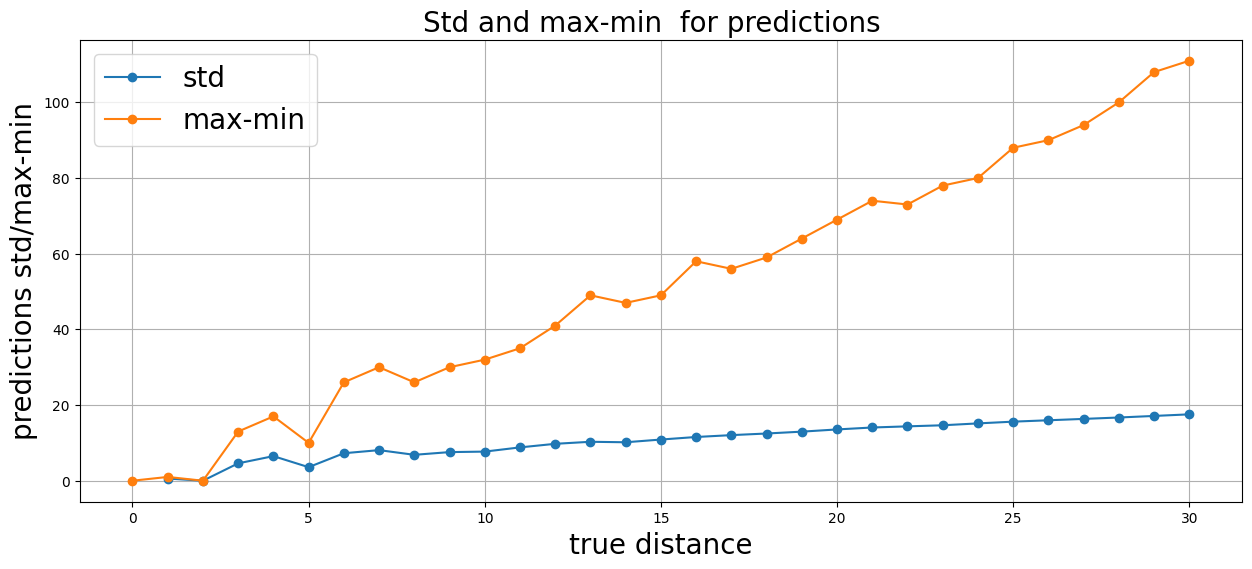

<timed exec>:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


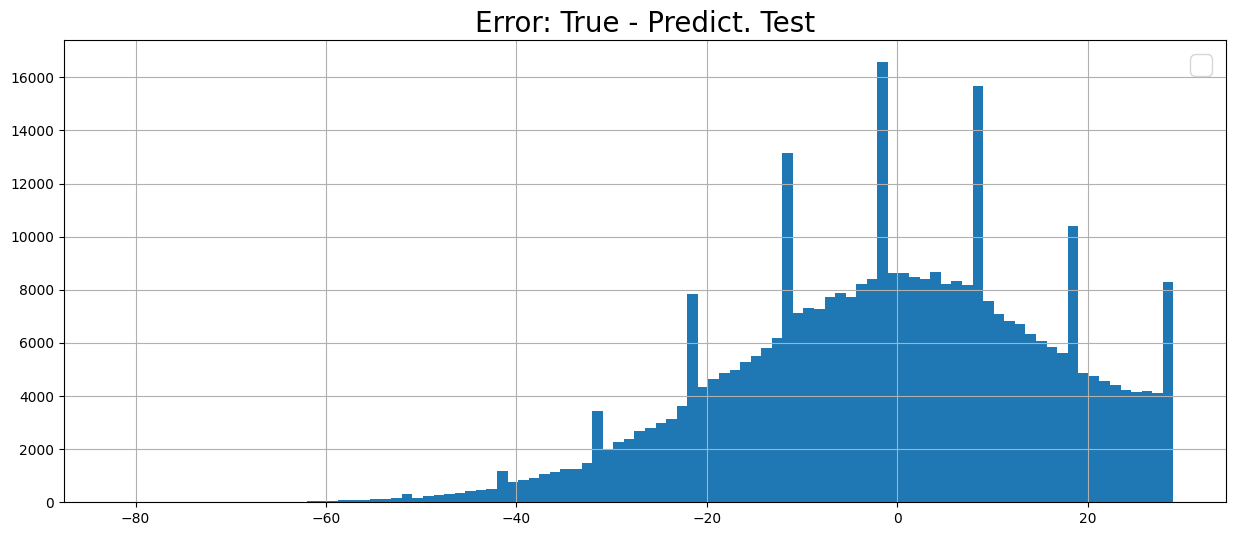

CPU times: user 2.2 s, sys: 190 ms, total: 2.39 s
Wall time: 2.39 s


,Model,Spearman,Pearson,PredictTime,Test
1,CNN_ch64-128_k3_epochs100_rwlen378_n_rw10000,0.239,0.257,1.195,"torch.Size([378, 28])"


In [79]:
%%time

# # Take all states constructed by BFS - convert them to torch tensor
# all_states = torch.zeros( size = (len(list_all_states), list_all_states[0].shape[0] ),  dtype =dtype, device = device )
# for k in range(len(list_all_states)):
#     all_states[k,:] = list_all_states[k]

all_states = array_states_all_saved
list_distances = list_distances_save


# Compute their neigbours
neigb = get_neighbors(all_states, tensor_generators)
# print( neigb.shape )
      
# Compute model predictions

neigb_flat = neigb.reshape(-1, neigb.shape[-1])
y_pred = torch.zeros((neigb_flat.shape[0], 1), device=device)
batch_size_loc = 1024
model.eval()
with torch.no_grad():
    for i_batch in range(0, neigb_flat.shape[0], batch_size_loc):
        i_end_batch = min(i_batch + batch_size_loc, neigb_flat.shape[0])
        y_pred[i_batch:i_end_batch] = model(neigb_flat[i_batch:i_end_batch])

y_pred = y_pred.reshape(neigb.shape[0], neigb.shape[1], 1)

#here
target_scale = float(max(CFG['n_random_walk_length'] - 1, 1))
y_pred = restore_regression_targets(y_pred, target_scale)


# print( y_pred.shape )

# Bellman's equation / Q-learning for graphs update: 
# V(g) = 1 + min_{neigb} V (neigb ) 
y_pred = 1 + torch.min(y_pred, dim=1)[0]

# Clip everthing to 1 and origin to 0
y_pred = torch.clamp_min(y_pred, 1 ) 
# Boundary condition - origin is in zero: 
y_pred[0]=0

# Rounding - since true distance is integer - but it does not seem to improve 
y_pred = torch.round(y_pred)



#######################################################################################
# Plots for error analysis
#######################################################################################

y_pred = y_pred.detach().cpu().numpy().ravel() #  =  convert_to_numpy( y_pred  ,y_pred ) 
y_test = np.array( list_distances )

plt.figure(figsize=(15,6))
plt.plot(y_pred )
plt.title('Predictions ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('index',fontsize = 20 )
plt.grid()
plt.show()

d = pd.DataFrame()
d['pred'] = y_pred
d['true'] = y_test
res = d.groupby('true')['pred'].agg(['mean', 'min', 'max'])
st = d.groupby('true')['pred'].agg(['std'])
plt.figure(figsize=(15,6))
plt.plot(res, 'o-',label = res.columns )
plt.plot(res['mean']+st['std'], 'o-',label = 'mean+std' )
plt.plot(res['mean']-st['std'], 'o-',label = 'mean-std' )
plt.title('Predictions vs true distance ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions',fontsize = 20 )
plt.grid()
plt.show()

plt.figure(figsize=(15,6))
plt.plot(st['std'], 'o-', label = 'std' )
plt.plot(res['max']-res['min'],'o-', label = 'max-min' )
plt.title('Std and max-min  for predictions  ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions std/max-min',fontsize = 20 )
plt.grid()
plt.show()

y_true = y_test
er = y_true - y_pred
plt.figure(figsize=(15,6))
plt.hist(er, bins = 100)
plt.title('Error: True - Predict. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()


r2_test = r2_score(y_test, y_pred)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred)))
spearmanr_test = stats.spearmanr(y_test, y_pred).statistic
pearson_test = np.corrcoef(y_test, y_pred)[0,1]
#res.statistic


df_stat = pd.DataFrame()
IX = len(df_stat)+1

df_stat.loc[IX,'Model'] = str_modeling_inf
# df_stat.loc[IX,'r2 Test'] = r2_test
#df_stat.loc[IX,'r2 Train'] = r2_train
# df_stat.loc[IX,'rmse Test'] = rmse_test
#df_stat.loc[IX,'rmse Train'] = rmse_train
df_stat.loc[IX,'Spearman'] = spearmanr_test
df_stat.loc[IX,'Pearson'] = pearson_test
#df_stat.loc[IX,'Spearman Train'] = spearmanr_train
#df_stat.loc[IX,'FitTime'] = np.round(fit_time,3)
df_stat.loc[IX,'PredictTime'] = np.round(predict_time,3)
#df_stat.loc[IX,'Train'] = str(X_train.shape)
df_stat.loc[IX,'Test'] = str(X_test.shape)

df_stat.round(3)

# Modified DQN training 

In [80]:
%%time
n_epochs_dqn = CFG['n_epochs_dqn']
flag_dqn_round = CFG['flag_dqn_round']
n_random_walks_to_generate = CFG['n_random_walks_to_generate_dqn']
print('n_epochs:', n_epochs_dqn)
verbose_loc = 10
t1 = time.time()
if n_epochs_dqn > 0:
    
    i_epoch_best = 0
    list_epoch_train_loss = []
    for epoch in range(n_epochs_dqn):
        #    torch.cuda.empty_cache()
        tt0 = time.time()
        X_train, y_train = random_walks(list_generators, n_random_walk_length=n_random_walk_length, 
                                        n_random_walks_to_generate=n_random_walks_to_generate, 
                                        n_random_walks_steps_back_to_ban = n_random_walks_steps_back_to_ban, 
                                        random_walks_type = random_walks_type, #'simple', 
                                        state_rw_start = state_destination)

        if verbose_loc >= 100:
            print('Epoch:', epoch ,  'RW-Generation Time: %.1f'%(time.time() - tt0) )
        t_rw = time.time() - tt0

        
        # Compute their neigbours
        neigb = get_neighbors(X_train, tensor_generators)
        # print( neigb.shape )

        # Compute model predictions by batches, and Bellman's equation update
        tt0 = time.time()
        n_states_all = X_train.shape[0]
        y_bellman = torch.zeros(X_train.shape[0], device = device, dtype = torch.float  )
        model.eval()
        n_moves = neigb.shape[1]

    with torch.no_grad():
        for i_start_batch in range(0, n_states_all, batch_size):
            i_end_batch = min([i_start_batch + batch_size, n_states_all])
            neighb_batch = neigb[i_start_batch:i_end_batch, :, :]
            neighb_batch_flat = neighb_batch.reshape(-1, neighb_batch.shape[-1])
            y_pred = model(neighb_batch_flat).reshape(-1, n_moves)

            target_scale = float(max(CFG['n_random_walk_length'] - 1, 1))
            y_pred = restore_regression_targets(y_pred, target_scale)

            
            y_pred = 1 + torch.min(y_pred, dim=1)[0]
            y_bellman[i_start_batch:i_end_batch] = y_pred.reshape(-1,)

                
        # Boundary conditions and restrictions coming from the diffusion distance 
        # Сliping (which also partly induce boundary conditions - they will be set to values less than zero - we need exactly zero ) 
        y_train = torch.min( y_bellman, y_train  )
        # Clip everthing to 1 and 
        y_train = torch.clamp_min(y_train, 1 ) 
        # Boundary condition - at origin distance is zero: 
        # (It is not complete boundary condition - since there can be other states which come to origin after many steps ) 
        y_train[:n_random_walks_to_generate] = 0
        # Rounding since distances are integers positive numbers: 
        #flag_dqn_round = 1
        if flag_dqn_round:
            y_train = torch.round( y_train )
        
        if verbose_loc >= 100:
            print('Epoch:', epoch ,  'Bellman Time: %.2f'%(time.time() - tt0) )
        t_bellman = time.time() - tt0

        
        # Shuffle train data and 
        #y_train = y_train.float()
        indices = torch.randperm(X_train.shape[0])
        X_train = X_train[indices] 
        y_train = y_train[indices] 

        
        tt0 = time.time()
        model.train()
        # Neural network train by batches (not to crash RAM)
        n_states_all =  X_train.shape[0]
        cc = 0; train_loss = 0.0
        for i_start_batch  in range(0,n_states_all,batch_size ):
            i_end_batch = min( [i_start_batch + batch_size,  n_states_all ] )
            
            # Forward
            outputs = model(X_train[i_start_batch:i_end_batch])
            loss = criterion(outputs.squeeze(), y_train[i_start_batch:i_end_batch])
            
            # Backward and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item(); 
            cc+=1
        train_loss /= cc
        list_epoch_train_loss.append( train_loss )
        t_train = time.time() - tt0

        if verbose_loc >= 100:
            print('Epoch:', epoch ,  'Optimize Time: %.2f'%(time.time() - tt0) )

            print('epoch:', epoch ,'train_loss:', np.round(train_loss,4),'Time:', np.round(time.time()-t1,2) )

        if verbose_loc >= 10:
            if epoch% (verbose_loc) == 0:
                print('epoch:', epoch ,'train_loss:', np.round(train_loss,4),'Time:', np.round(time.time()-t1,2),
                     'RW %.2f'%(t_rw),'Bellman %.2f'%(t_bellman),'Train %.2f'%(t_train),    )

    print('Training finished. Timing:', np.round(time.time()-t1, 1) )

n_epochs: 0
CPU times: user 65 μs, sys: 2 μs, total: 67 μs
Wall time: 64.4 μs


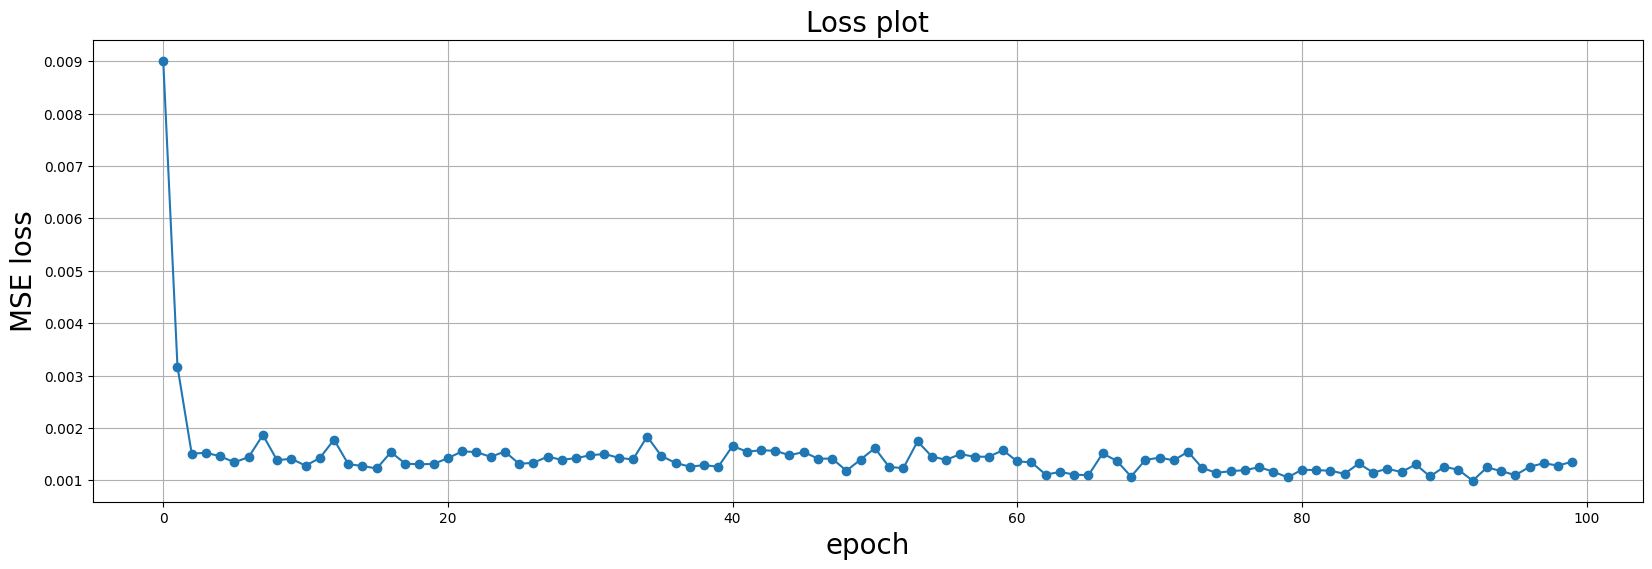

In [82]:
fig = plt.figure(figsize = (20,6 ) )
plt.plot( list_epoch_train_loss, 'o-'  )
plt.title('Loss plot', fontsize = 20 )
plt.xlabel('epoch',fontsize = 20 )
plt.ylabel('MSE loss', fontsize=20)
plt.grid()
plt.show()

<timed exec>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
<timed exec>:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


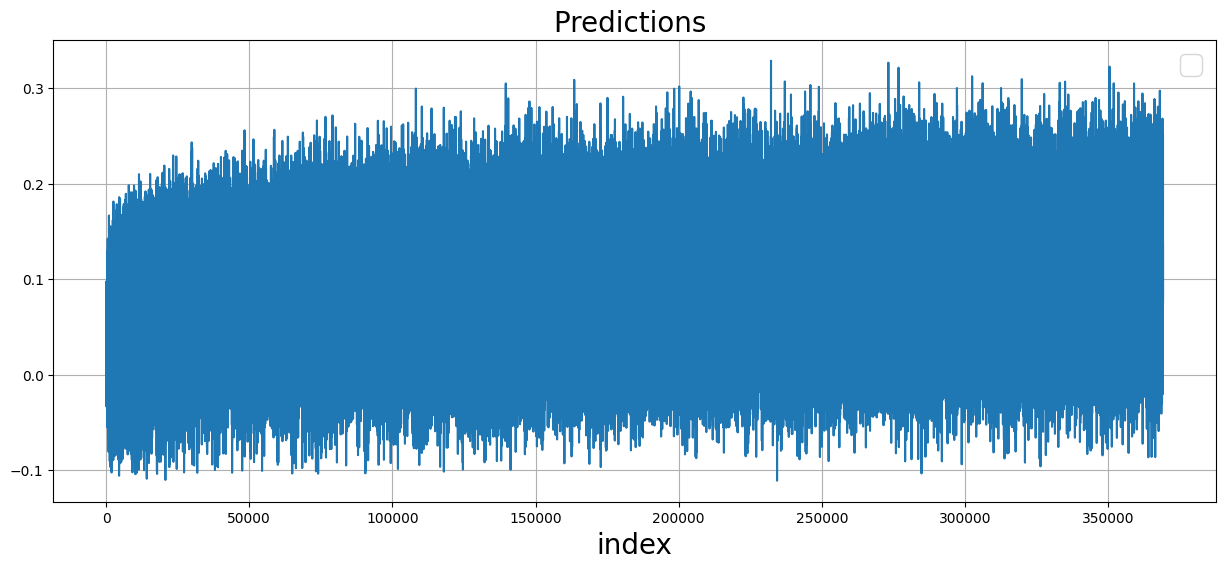

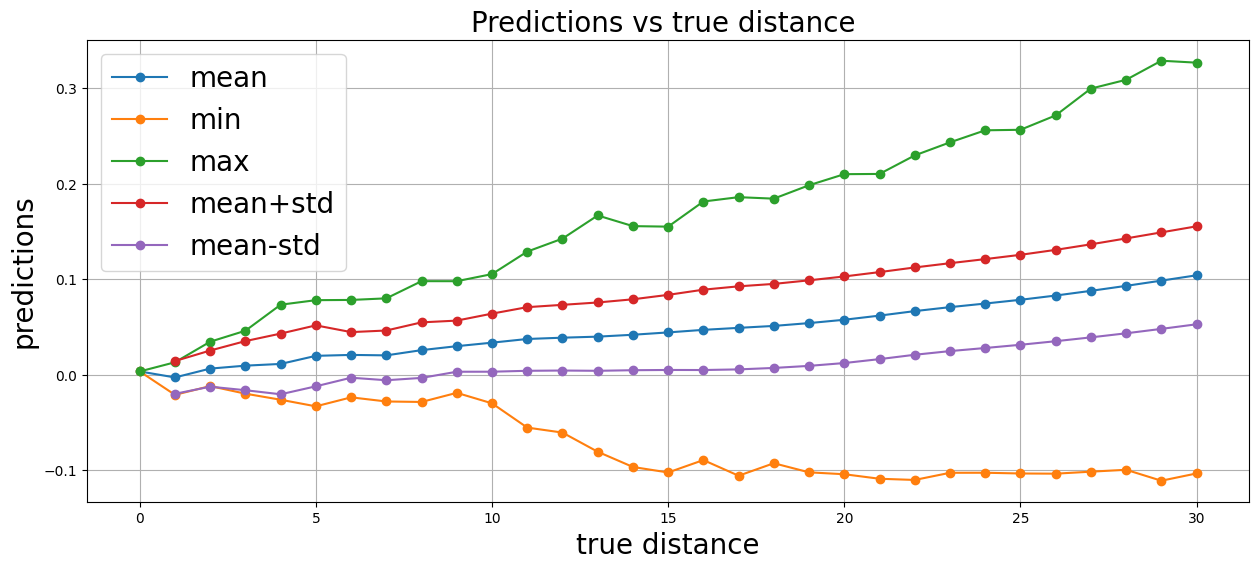

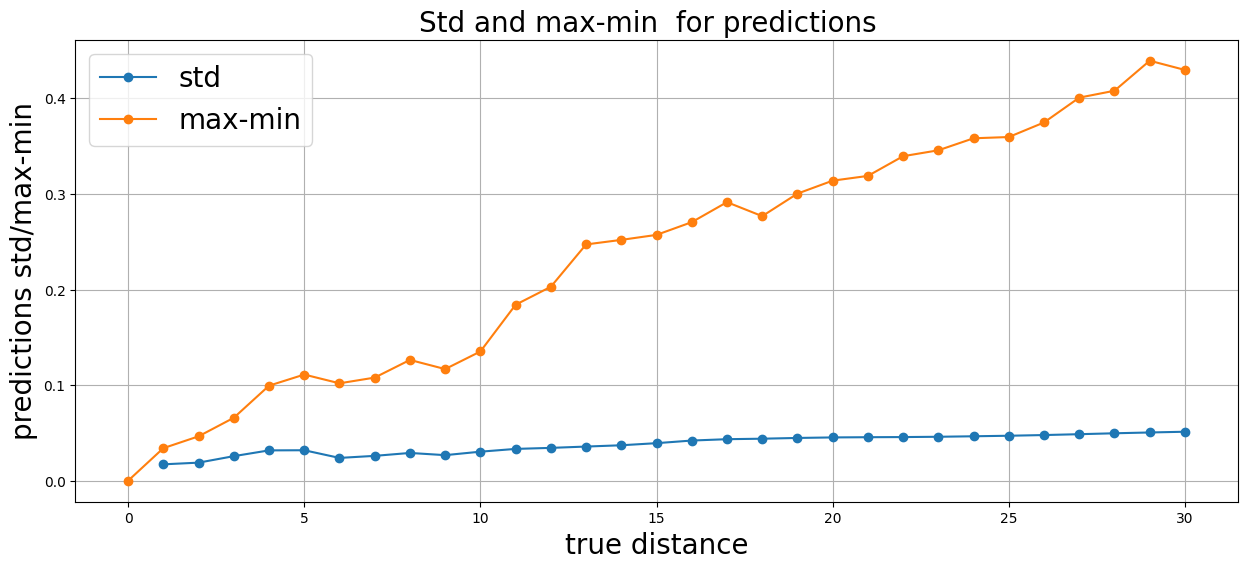

<timed exec>:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


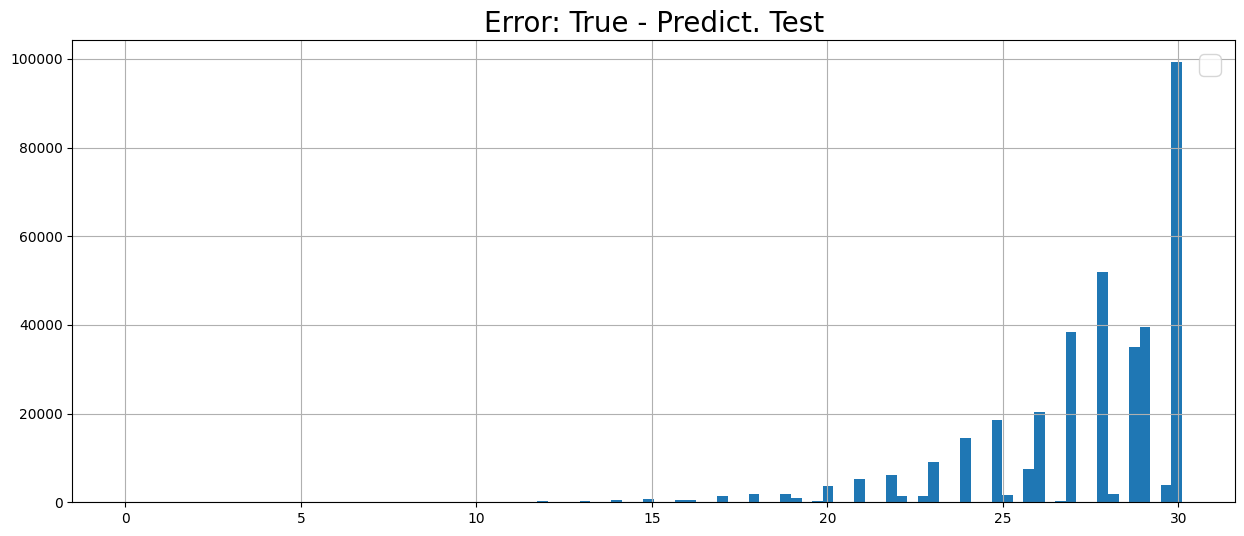

CPU times: user 2.99 s, sys: 65.7 ms, total: 3.06 s
Wall time: 3.07 s


,Model,Spearman,Pearson,PredictTime,Test
1,CNN_ch64-128_k3_epochs100_rwlen378_n_rw10000,0.24,0.26,1.195,"torch.Size([378, 28])"


In [84]:
%%time
# all_states = torch.zeros( size = (len(list_all_states), list_all_states[0].shape[0] ),  dtype =dtype, device = device )
# for k in range(len(list_all_states)):
#     all_states[k,:] = list_all_states[k]


all_states = array_states_all_saved
list_distances = list_distances_save

all_states_tensor = torch.tensor(all_states, dtype=torch.float32)
dataset = TensorDataset(all_states_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size)

# Batched prediction
model.eval()
y_pred_list = []

with torch.no_grad():
    for batch in dataloader:
        batch_states = batch[0].to(device) 
        batch_pred = model(batch_states)
        y_pred_list.append(batch_pred.detach().cpu())


y_pred = torch.cat(y_pred_list).numpy().ravel()
y_test = np.array(list_distances)

#######################################################################################
# Plots for error analysis
#######################################################################################

# y_pred = y_pred.detach().cpu().numpy().ravel() #  =  convert_to_numpy( y_pred  ,y_pred ) 
# y_test = np.array( list_distances )

plt.figure(figsize=(15,6))
plt.plot(y_pred )
plt.title('Predictions ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('index',fontsize = 20 )
plt.grid()
plt.show()

d = pd.DataFrame()
d['pred'] = y_pred
d['true'] = y_test
res = d.groupby('true')['pred'].agg(['mean', 'min', 'max'])
st = d.groupby('true')['pred'].agg(['std'])
plt.figure(figsize=(15,6))
plt.plot(res, 'o-',label = res.columns )
plt.plot(res['mean']+st['std'], 'o-',label = 'mean+std' )
plt.plot(res['mean']-st['std'], 'o-',label = 'mean-std' )
plt.title('Predictions vs true distance ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions',fontsize = 20 )
plt.grid()
plt.show()

plt.figure(figsize=(15,6))
plt.plot(st['std'], 'o-', label = 'std' )
plt.plot(res['max']-res['min'],'o-', label = 'max-min' )
plt.title('Std and max-min  for predictions  ', fontsize = 20)
plt.legend(fontsize = 20 )
plt.xlabel('true distance',fontsize = 20 )
plt.ylabel('predictions std/max-min',fontsize = 20 )
plt.grid()
plt.show()

y_true = y_test
er = y_true - y_pred
plt.figure(figsize=(15,6))
plt.hist(er, bins = 100)
plt.title('Error: True - Predict. Test', fontsize = 20)
plt.legend(fontsize = 20 )
plt.grid()
plt.show()


r2_test = r2_score(y_test, y_pred)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred)))
spearmanr_test = stats.spearmanr(y_test, y_pred).statistic
pearson_test = np.corrcoef(y_test, y_pred)[0,1]
#res.statistic


df_stat = pd.DataFrame()
IX = len(df_stat)+1

df_stat.loc[IX,'Model'] = str_modeling_inf
# df_stat.loc[IX,'r2 Test'] = r2_test
#df_stat.loc[IX,'r2 Train'] = r2_train
# df_stat.loc[IX,'rmse Test'] = rmse_test
#df_stat.loc[IX,'rmse Train'] = rmse_train
df_stat.loc[IX,'Spearman'] = spearmanr_test
df_stat.loc[IX,'Pearson'] = pearson_test
#df_stat.loc[IX,'Spearman Train'] = spearmanr_train
#df_stat.loc[IX,'FitTime'] = np.round(fit_time,3)
df_stat.loc[IX,'PredictTime'] = np.round(predict_time,3)
#df_stat.loc[IX,'Train'] = str(X_train.shape)
df_stat.loc[IX,'Test'] = str(X_test.shape)

df_stat.round(3)

# State to be solved

In [85]:
%%time
#state_destination = torch.arange( len(list_generators[0] ), dtype = dtype, device = device )
print('state_destination:', state_destination)

# solve_random_or_longest_state = 'solve_random_state'
solve_random_or_longest_state = CFG['solve_random_or_longest_state']
print('solve_random_or_longest_state:',solve_random_or_longest_state)
if solve_random_or_longest_state == 'solve_random_state':
    n_scrambles_starting_state = len(list_generators)**3*100 #1000 
    state_start = state_destination.clone()
    for k in range(n_scrambles_starting_state):
        IX_move = np.random.randint(0, len(list_generators), dtype = int) # random moves indixes
        state_start = state_start[ list_generators[IX_move]] # all_moves[IX_moves,:] ] 
else:
    n = len(list_generators[0])
    p = np.arange(n)
    # Swap (0,2)
    p[0], p[1] = p[1], p[0]
    i = 2
    while i < n-i+1:
        #print(i, n-i+1)
        p[i], p[n-i+1] = p[n-i+1], p[i]
        i += 1
    permutation_longest = torch.tensor( p , dtype = dtype, device = device )    
    state_start = permutation_longest 
    print('custom_start_state:', permutation_longest)

#print('state_destination:', state_destination)
print('state_start (state to be solved): ', state_start)


state_destination: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27], device='cuda:0')
solve_random_or_longest_state: solve_random_state
state_start (state to be solved):  tensor([ 2,  3,  4,  5, 14,  0,  8, 25, 26, 16, 11, 22, 17, 12, 15,  1, 13, 20,
         7,  6,  9, 24, 23, 10, 18, 27, 19, 21], device='cuda:0')
CPU times: user 93.7 ms, sys: 5 μs, total: 93.7 ms
Wall time: 93.5 ms


# Beam Search Torch

In [86]:
def get_unique_states(states: torch.Tensor, vec_hasher = 'Auto',device = 'Auto') -> torch.Tensor:
    '''
    Return matrix with unique rows for input matrix "states" 
    I.e. duplicate rows are dropped.
    For fast implementation: we use hashing via scalar/dot product.
    Note: output order of rows is different from the original. 

    Note: that implementation is 30 times faster than torch.unique(states, dim = 0) - because we use hashes  (see K.Khoruzhii: https://t.me/sberlogasci/10989/15920)
    Note: torch.unique does not support returning of indices of unique element so we cannot use it 
    That is in contrast to numpy.unique which supports - set: return_index = True     
    '''

    if vec_hasher == 'Auto':
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
        
    # Preprare vector which will used for hashing - to avoid revisiting same states 
    if vec_hasher == 'Auto':
        max_int =  int( (2**62) )
        dtype_for_hash = torch.int64
        vec_hasher = torch.randint(-max_int, max_int+1, size=(state_size,), device=device, dtype=dtype_for_hash)     
    
    # Hashing rows of states matrix: 
    hashed = torch.sum(vec_hasher * states, dim=1) # Compute hashes. 
        # It is same as matrix product torch.matmul(hash_vec , states ) 
        # but pay attention: such code work with GPU for integers 
        # While torch.matmul - does not work for GPU for integer data types, 
        # since old GPU hardware (before 2020: P100, T4) does not support integer matrix multiplication 
    
    # Sort
    hashed_sorted, idx = torch.sort(hashed)
    # Mask selects elements which are different from the consequite - that is unique elements (since vector is sorted on the previous step)
    mask = torch.concat((torch.tensor([True], device = device), 
                         (hashed_sorted[1:] - hashed_sorted[:-1]) != 0))
    return states[idx][mask]

# Test run:
s = get_unique_states(torch.arange(n_permutations_length, device = device ).view(1, -1  ).expand(10, -1 ).clone())
print(s)
s.shape,s.dtype

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27]], device='cuda:0')


(torch.Size([1, 28]), torch.int64)

## Beam search params

In [87]:
%%time
print(CFG)
print()
##################################################################################
# Beam search params
##################################################################################


#beam_width = 1000
beam_width =  CFG['beam_width']
print('beam_width:', beam_width)
# Coefficient to combine previous cost and new value typically 0...1 (attenuation of history) 
alpha_previous_cost_accumulation = CFG['alpha_previous_cost_accumulation']
print('alpha_previous_cost_accumulation:', alpha_previous_cost_accumulation  )
# Maximum steps to make:
n_steps_limit = CFG['n_steps_limit']
print('n_steps_limit:',n_steps_limit)

ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted = CFG['ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted']
print('ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted:',ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted)
beam_search_models_or_heuristics = CFG['beam_search_models_or_heuristics']#  'model_torch'; # 'Hamming'
print('beam_search_models_or_heuristics:',beam_search_models_or_heuristics)
batch_size = CFG['batch_size']
print('batch_size:', batch_size )
n_steps_back_to_ban = CFG['n_beam_search_steps_back_to_ban']
print('n_steps_back_to_ban:',n_steps_back_to_ban)
beam_search_models_or_heuristics = CFG['beam_search_models_or_heuristics']#  'model_torch'; # 'Hamming', 'model_with_predict': # Catboost or Sklearn 
print('beam_search_models_or_heuristics:',beam_search_models_or_heuristics)
 

# To support the optional LRX-style heuristic, look for the simple swap (0,1) if it exists.
state_size = len(list_generators[0])
X_loc = np.array( [1,0] + list(np.arange(2,n)) )
i_position_X_in_list_generators = -1
for k in range(len(list_generators)):
    if np.all( list_generators[k] == X_loc ) : 
        i_position_X_in_list_generators = k
        break
print('i_position_X_in_list_generators:',i_position_X_in_list_generators )     
verbose = 100

print()


print('state_destination:', state_destination)
print()
print('state_start (state to be solved): ', state_start)
print()

{'n_permutations_length': 28, 'random_walks_type': 'non-backtracking-beam', 'n_random_walk_length': 378, 'n_random_walks_to_generate': 512, 'n_random_walks_steps_back_to_ban': 8, 'model_type': 'CNN', 'list_layers_sizes': [128], 'cnn_channels': [32, 64], 'cnn_kernel_size': 5, 'run_cnn_hyperparameter_sweep': True, 'cnn_sweep_params': {'cnn_channels': [[32, 64], [64, 128]], 'cnn_kernel_size': [3, 5], 'lr': [0.001, 0.0003], 'batch_size': [512], 'n_epochs': [100], 'n_random_walks_to_generate': [512], 'n_test_random_walks_to_generate': [256]}, 'n_epochs': 100, 'batch_size': 512, 'lr': 0.0003, 'n_epochs_dqn': 0, 'flag_dqn_round': False, 'n_random_walks_to_generate_dqn': 1000, 'beam_search_torch': True, 'beam_search_Fironov': False, 'beam_width': 65536, 'n_steps_limit': 3136, 'alpha_previous_cost_accumulation': 0, 'beam_search_models_or_heuristics': 'model_torch', 'ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted': False, 'n_beam_search_steps_back_to_ban': 32, 'solve_random_or_longest_sta

## Beam search torch main loop

In [88]:
%%time
if CFG['beam_search_torch']:

    n_generators = len(list_generators)
    
    t0 = time.time()
    
    flag_found_destination = False
    
    
    if 1:
        # Initialize array of states 
        array_beam_states = state_start.view(1, state_size  ).clone().to(dtype).to(device)
    
    
        # Hash initial states. Intialize storage
        if n_steps_back_to_ban > 0:
            # Hashes via vector product - extremely simple and fast
            # Implementation - equivalent to matmul, but matmul is not supported for ints in torch (on GPU <= 2018) - that is way round
            hash_initial_state = torch.sum( state_start.view(-1, state_size  ) * vec_hasher, dim=1) # Compute hashes 
            # Storage for hashes - 2d array: 
            vec_hashes_current = hash_initial_state.expand( beam_width * n_generators  , n_steps_back_to_ban ).clone()
            # Intialize index for hash storage
            # Newly obtained hash vectors will be stored in 2d array vec_hashes_current 
            # The position/column for storage: i_cyclic_index_for_hash_storage
            i_cyclic_index_for_hash_storage = 0 # Will be updated modula n_steps_back_to_ban, i.e. from 0 to n_steps_back_to_ban-1
    
        ##########################################################################################
        # Main loop 
        # 1. Apply all moves to all states in current beam - get new states candidates
        # 2. Select only unique states - that appears to be critical - otherwise beam becomes over-populated by duplicates and all the diversity ideas is lost
        # 3. Check  destination-state:  found or not
        # 4. Select those states which were not visited on "NNN" previous steps. To make it fast we uses hashes:
        # 4.1. Compute hashes of these states just by scalar multiplication on random hash vector - get single int64 as a hash
        # 4.2. Choose only those states which hashes are new - not in the stored history of hashes
        # 5 Compute value function for all states - model prediction or heuristics
        # 5b Select only desired number of states - beam_width "best" states 
        ##########################################################################################    
        for i_step in range(1,n_steps_limit+1):
            t_moves = t_hash = t_isin =  0; t_full_step = time.time() # Time profiling
            t_unique_els = 0 
            
            # 1. Create new states: 
            # Apply all generators to all current states at once
            # array_new_states: 2d array (n_random_walks_to_generate * n_generators  ) x state_size
            t1 = time.time()
            if not ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted:
                array_new_states = get_neighbors(array_beam_states,tensor_generators  ).flatten(end_dim=1) # Flatten converts 3d array to 2d
            
            else:
                # Basically same as above - result will be application of all moves to all beam states
                # but do it move by move, in order to check specific heuristic condition for some moves
                # I.e. implement  "Fironov's X-condition check"
                # That is not apply transposition (0,1) if v[0],v[1] are already sorted 
    
                # Prepare storage for new states: 
                array_new_states = torch.empty( (0,array_beam_states.shape[1]) , device=device, dtype = dtype)
                
                # Technical preparation: to apply permutations to array we need the trick:
                # naively it is: array[ :, IX_array], but actually we need  to write array[ range(N)[:, np.newaxis], IX_array  ]
                row_indices = np.arange( array_beam_states.shape[0] )[:, np.newaxis]
                
                # Loop over moves:
                for ii1, move in enumerate(list_generators):
                    
                    if (ii1 != i_position_X_in_list_generators):
                        # Make move - one move to all beam states at once: 
                        array_states_tmp = array_beam_states[row_indices,move]
                        
                    else:
                        # Make moves with exceptions: 
                        # Do not make transposition of 0,1 if they are already sorted:
                        mask_X_condtion = array_beam_states[:,0] > array_beam_states[:,1]
                        row_indices = np.arange( mask_X_condtion.sum().item() )[:, np.newaxis]
                        array_states_tmp = array_beam_states[mask_X_condtion][row_indices,move]
                   
                    # array_states_tmp = get_unique_states(array_states_tmp) # Do this later - Can do it for all states at once later for speed-up
                    
                    array_new_states = torch.concatenate([array_new_states, array_states_tmp],axis = 0)
            
            t_moves += (time.time() - t1)
    
            # 2. Take only unique states 
            # surprise: THAT IS CRITICAL for beam search performance !!!!
            # if that is not done - beam search  will not find the desired state - quite often
            # The reason - essentianlly beam can degrade, i.e. can be populated by copy of only one state 
            # It is surprising that such degradation  happens quite often even for beam_width = 10_000 - but it is indeed so          
            t1 = time.time()
            array_new_states = get_unique_states(array_new_states)
            t_unique_els += (time.time() - t1)
            
            # 3. Check destination state found 
            vec_tmp = torch.all(array_new_states == state_destination, axis =1) # Compare state_destination and each row array_of_states 
            flag_found_destination = torch.any(vec_tmp).item() # Check for coincidence
            if flag_found_destination:
                if verbose >= 1:
                    print('Found destination state. ', 'i_step:', i_step, ' n_ways:', (vec_tmp).sum()) 
                break   
            
            # 4. Nonbacktracking - forbid visits states visited before
            if n_steps_back_to_ban > 0:      
                # 4.1 Compute hashes
                # Compute hash. For non-backtracking, i.e. selection of  states, which were not visited  before. 
                t1 = time.time()
                vec_hashes_new = torch.sum(array_new_states * vec_hasher, dim=1) # Compute hashes 
                # That is equivalent to matmul, but matmul is not supported for ints in torch (on GPU <= 2018) - that is way round
                t_hash += (time.time() - t1)
                #  print('hashed', t_hash )
    
                # 4.2 Select only states not seen before
                # Nonbacktracking - select states not visited before 
                t1 = time.time()
                mask_new = ~torch.isin(vec_hashes_new, vec_hashes_current.view(-1), assume_unique=False)
                t_isin += (time.time() - t1)
                mask_new_sum = mask_new.sum().item()
                if mask_new_sum > 0 :
                    # Select only new states - not visited before
                    array_new_states = array_new_states[mask_new,:]
                else:
                    # Stagnation cannot find new states 
                    # In futute versions consider restarts 
                    flag_found_destination = False 
                    # i_step = -1
                    if verbose >= 1:
                        print('Cannot find new states. i_step:',i_step, )
                    break
                # Update hash storage 
                # Pay attention - we store hashes for ALL obtained states not only for those selected - that gives us improvement:
                # We improve the chances that states obtaine on i_step will be on true graph distance i_step - our ideal goal.
                # Which might not always be the case since random walk may create loops. 
                # All the states which are achieved - they need not more than i_step steps - so it is better to ban them all
                # Thus we improve chances that the next states will increase the true graph distance
                i_cyclic_index_for_hash_storage = (i_cyclic_index_for_hash_storage + 1 ) % n_steps_back_to_ban
                i_tmp = len(vec_hashes_new)
                vec_hashes_current[:i_tmp, i_cyclic_index_for_hash_storage ] = vec_hashes_new  
    
            # 5. Estimate states and select top beam_width ones 
            # ML-model inference - estimate distance of new states to the destination state    
            t0 = time.time()
            q_value = torch.tensor([0])
            if array_new_states.shape[0] > beam_width: # If we have not so many states - we take them all - no need for ML-model
    
                # Compute heuristic distance to destination state
                if beam_search_models_or_heuristics == 'model_torch': 
                    model.eval()
                    with torch.no_grad():
                        n_states_all = array_new_states.shape[0]
                        q_value = torch.zeros( n_states_all, device = device )
                        for i_start_batch  in range(0,n_states_all,batch_size ):     
                            i_end_batch = min( [i_start_batch + batch_size,  n_states_all ] )
                            q_value[i_start_batch:i_end_batch]  = model(array_new_states[i_start_batch:i_end_batch ,: ]).view(-1)
                    # Get indices of the smallest `beam_width` values
                    idx = torch.argsort(q_value)[:beam_width]
                    # Select rows based on the indices
                    array_beam_states = array_new_states[idx, :]
                elif beam_search_models_or_heuristics == 'model_with_predict': # Catboost or Sklearn 
                
                    # ML-model inference - estimate distance of new states to the destination state
                    q_value = model.predict(array_new_states.detach().cpu().numpy() )
                    # Take only "beam_width" of the best states (i.e. most nearest to destination according to the model estimate)
                    idx = np.argsort(q_value)[:beam_width]
                    array_beam_states = array_new_states[idx,:]
                    
                elif beam_search_models_or_heuristics == 'Hamming': 
                    # Here it is Hamming distance, but can be neural net predictor:
                    q_value = torch.sum( (array_new_states - state_destination ) !=0 , axis = 0 )
                    # Get indices of the smallest `beam_width` values
                    idx = torch.argsort(q_value)[:beam_width]
                    # Select rows based on the indices
                    array_beam_states = array_new_states[idx, :]                
                else:
                    raise Exception("Unrecognized models_or_heuristics: " + str( beam_search_models_or_heuristics ))
                    
            else:
                array_beam_states = array_new_states
            predict_time = time.time() - t0        
    
            if verbose >= 10:
                if (i_step-1) % 10 == 0:
                    if isinstance(q_value, torch.Tensor): q_value = q_value.detach().cpu().numpy()
                    t_full_step = time.time()-t_full_step
                    print('Step:',i_step, #  'Visited states:', len(set_seen_states), 
                          'Beam (not cummulative) min:',  '%.2f'%np.min( q_value),
                          'median:',  '%.2f'%np.median( q_value),
                          'max:',  '%.2f'%np.max( q_value))
            if verbose >= 100:
                if (i_step-1) % 15 == 0:
                    print('Time: %.1f'%(time.time() - t0 ),'t_moves  %.3f, t_hash  %.3f, t_isin %.3f, t_unique_els  %.3f, t_full_step %.3f'%(t_moves , 
                          t_hash , t_isin , t_unique_els, t_full_step))
                      
    
            #raise Exception("Just stop here")
    
    print()
    print(CFG)
    
    print()
    print('beam_width:', beam_width)
    print('n=',len(list_generators[0] ) )
    print('n(n-1)/2=', int(n*(n-1)/2))
    print('Found Path Length:', i_step , 'flag_found_destination:',flag_found_destination, )
    #print(path_found)        

Step: 1 Beam (not cummulative) min: 0.00 median: 0.00 max: 0.00
Time: 0.0 t_moves  0.000, t_hash  0.000, t_isin 0.002, t_unique_els  0.000, t_full_step 0.003
Step: 11 Beam (not cummulative) min: 0.00 median: 0.00 max: 0.00
Time: 0.0 t_moves  0.000, t_hash  0.000, t_isin 0.003, t_unique_els  0.000, t_full_step 1778290269.301
Step: 21 Beam (not cummulative) min: 0.00 median: 0.00 max: 0.00
Step: 31 Beam (not cummulative) min: 0.60 median: 0.92 max: 1.11
Time: 0.1 t_moves  0.000, t_hash  0.000, t_isin 0.003, t_unique_els  0.001, t_full_step 0.060
Step: 41 Beam (not cummulative) min: 0.47 median: 0.80 max: 1.02
Time: 0.1 t_moves  0.000, t_hash  0.000, t_isin 0.004, t_unique_els  0.001, t_full_step 1778290270.366
Step: 51 Beam (not cummulative) min: 0.42 median: 0.71 max: 0.91
Step: 61 Beam (not cummulative) min: 0.38 median: 0.62 max: 0.85
Time: 0.1 t_moves  0.000, t_hash  0.000, t_isin 0.005, t_unique_els  0.001, t_full_step 0.062
Step: 71 Beam (not cummulative) min: 0.29 median: 0.55 max

# Beam search S.Fironov's version


In [89]:
from collections import deque
# The deque (short for "double-ended queue") class from the collections module. 
# A deque is a list-like data structure optimized for fast appends and pops from both ends.

    # Key Features of deque: 
    # Fast O(1) append and pop operations on both ends (better than lists, which are O(n) for pops from the front).
    # Thread-safe for append/pop operations.
    # Supports max length (maxlen) to act as a circular buffer.

In [90]:
%%time
if CFG['beam_search_Fironov']:  
    t1 = time.time()
    
    ##################################################################################
    # Beam search params
    ##################################################################################
    
    
    #beam_width = 1000
    beam_width =  CFG['beam_width']
    print('beam_width:', beam_width)
    # Coefficient to combine previous cost and new value typically 0...1 (attenuation of history) 
    alpha_previous_cost_accumulation = CFG['alpha_previous_cost_accumulation']
    print('alpha_previous_cost_accumulation:', alpha_previous_cost_accumulation  )
    # Maximum steps to make:
    n_steps_limit = CFG['n_steps_limit']
    print('n_steps_limit:',n_steps_limit)
    
    ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted = CFG['ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted']
    
    beam_search_models_or_heuristics = CFG['beam_search_models_or_heuristics']#  'model_torch'; # 'Hamming'
    
    verbose = 100
    
    ##################################################################################
    # Main initializations 
    ##################################################################################
    
    # Main storage data:
    # Priority queue for the beam search; stores tuples of (cumulative cost, path, current state)
    queue_beam = deque([(0, [], state_start )] )
    
    # Set of all previously visited states 
    # We will ban visiting them again 
    set_seen_states = set( )
    set_seen_states.add(str(state_start))
    
    counter_length = 0 # Path length counter 
    flag_path_found = False
    path_found = []
    ##################################################################################
    # Main loop
    ##################################################################################
    while queue_beam: #  continue looping as long as queue is not empty. It should never be empty, unless graph is not conncected and path does not exists
        counter_length += 1
        #print('counter_length',counter_length)
        
        # Select top best states candidates - top-beam-width    
        queue_beam = deque(sorted(list(queue_beam), key=lambda x: x[0])[:beam_width])
    
        # Storage for newly generated states/costs/paths:
        # They will be obtained by applying all moves to all states in beam 
        queue_beam_next = deque()
    
        # That will be used just for monitoring - printing stat on obtained values 
        # Pay attention these are NOT cummulative costs 
        list_beam_q_values_for_monitoring = []
    
        # Loop via current beam:
        for cost, path, current_state in queue_beam:
            #print('cost, path, current_state',cost, path, current_state)
    
            # Loop via all possible moves 
            for i_action, action in enumerate(dict_generators.keys()):
    
                #Check conditions for reasonable moves, disregard unreasoanble
                # Condition proposed by S.Fironov - it is rather natural, is there theoretical proof ?
                if ban_p0_p1_transposition_if_p0_lt_p1_ie_already_sorted:
                    if action == 'X' and current_state[0] < current_state[1]: # Heuristics 
                        continue            
                if len(path) > 0 and path[-1] == action: # Koltsov3 generators are involutions
                   continue
     
                # Make a move (apply generator, i.e. go to neigbour node )
                generator =  tensor_generators[i_action, : ]
                next_state = current_state[ generator ]
    
                # Check destnation found: 
                if torch.all( next_state == state_destination) :
                    flag_path_found = True
                    path_found = path + [action]
                    break 
    
                # Check the next_state is new or visited before 
                if str(next_state) not in set_seen_states:
                    set_seen_states.add(str(next_state))
    
                    # Compute heuristic distance to destination state
                    if beam_search_models_or_heuristics == 'model_torch': 
                        model.eval()
                        with torch.no_grad():
                            q_value = model(next_state.reshape(1,-1)).item()
    
                    elif beam_search_models_or_heuristics == 'Hamming': 
                        # Here it is Hamming distance, but can be neural net predictor:
                        q_value = torch.sum( (next_state - state_destination ) !=0  ).item()
                    else:
                        raise Exception("Unrecognized models_or_heuristics: " + str( beam_search_models_or_heuristics ))
                    
                    list_beam_q_values_for_monitoring.append(q_value)
    
                    # Cummulative cost: 
                    total_cost = q_value + alpha_previous_cost_accumulation * cost  
                    queue_beam_next.append((total_cost, path + [action], next_state))
                    
                ###### End loop over actions/moves
            
            if flag_path_found: break  # Path found. Stop process
            ###### End loop over beam
        
        if flag_path_found: break  # Path found. Stop process
    
        if verbose >= 100:
            if counter_length % 10 == 0:        
                print('Step:',counter_length, 'Visited states:', len(set_seen_states), 
                      'Beam (not cummulative) min:',  '%.2f'%np.min( list_beam_q_values_for_monitoring),
                      'median:',  '%.2f'%np.median( list_beam_q_values_for_monitoring),
                      'max:',  '%.2f'%np.max( list_beam_q_values_for_monitoring),
                      'Time: %.1f'%(time.time() - t1 ))
                # print('new max len', len(path), len(queue), len(seen), 
                #       np.min(list_beam_q_values_for_monitoring), np.median(list_beam_q_values_for_monitoring),
                #       np.mean(list_beam_q_values_for_monitoring), np.max(list_beam_q_values_for_monitoring) )
            
        
        if counter_length > n_steps_limit:
            flag_path_found = False
            path_found = []
            break
    
    
        # Update the entire queu for new states/costs/paths:
        queue_beam = queue_beam_next
    
        ###### End loop iterations 
    
    print()
    print(CFG)
    
    print()
    print('beam_width:', beam_width)
    print('n=',len(list_generators[0] ) )
    print('n(n-1)/2=', int(n*(n-1)/2))
    print('Found Path Length:', len(path_found)  , 'flag_path_found:',flag_path_found, )
    print(path_found)

CPU times: user 6 μs, sys: 0 ns, total: 6 μs
Wall time: 8.11 μs


# Check path correctness

In [91]:
if CFG['beam_search_Fironov']:
   
    state = state_start.clone()
    print('state_start:',state_start)
    path = path_found
    for p in path:
        move = dict_generators[p]
        state = state[move]
    print(state)    
    print(state_destination)
    print('Path correct: ', torch.all( state ==  state_destination).item()  )
    
    def solution_checker(dict_generators, state_start, path,  state_destination ):
        state = state_start.clone()
        path = path_found
        for p in path:
            move = dict_generators[p]
            state = state[move]    
        flag_path_correct = torch.all( state ==  state_destination).item()
        return flag_path_correct
    
    flag_path_correct = solution_checker(dict_generators, state_start, path,  state_destination ) 
    print('flag_path_correct:',flag_path_correct)

# Final Timing

In [92]:
print('%.1f seconds passed total '%(time.time()-t0start) )
print('%.1f minutes passed total '%( (time.time()-t0start)/60)  )
print('%.2f hours passed total '%( (time.time()-t0start)/3600)  )

6527.1 seconds passed total 
108.8 minutes passed total 
1.81 hours passed total 


In [93]:
print('raw model min/max/mean:', y_pred.min().item(), y_pred.max().item(), y_pred.mean().item())


raw model min/max/mean: -0.11082743853330612 0.32849636673927307 0.0912388488650322
